<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch11_mathematical_tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11 — Mathematical Tools

> *"The mathematicians are the priests of the modern world."* — Bill Gaede

Quantitative finance is, at its core, applied mathematics. Every model — whether for option pricing, risk management, portfolio construction, or yield-curve construction — ultimately rests on a small set of recurring mathematical operations: **approximating** unknown functions, **optimizing** objectives subject to constraints, **integrating** payoffs against probability measures, and (less visibly) **manipulating expressions symbolically** to derive closed-form intermediates.

This chapter walks through Python's tooling for each of these four pillars:

| Topic | Use cases in finance |
|---|---|
| **Approximation** (regression & interpolation) | Yield-curve fitting, factor models, longstaff–schwartz Monte Carlo, implied vol surfaces |
| **Convex optimization** | Calibrating option-pricing models, expected-utility maximization, mean-variance portfolios |
| **Integration** | Risk-neutral pricing $V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[h(S_T)]$, expected losses, VaR |
| **Symbolic computation** | Derivations of Greeks, closed-form solutions, automatic differentiation of payoffs |

Throughout, our recurring test function is

$$f(x) = \sin(x) + \tfrac{1}{2}x$$

which combines a smooth oscillatory component with a linear drift — small enough to inspect by eye, rich enough to expose how each method handles **nonlinearity** and **smoothness**.

## Setup

We use **NumPy** for numerical arrays, **SciPy** subpackages for interpolation, optimization, and integration, **SymPy** for symbolic algebra, and **Matplotlib** for plotting. The original *Python for Finance* (2nd ed., 2018) text uses a few APIs that have since been deprecated; we patch around them transparently and note the changes inline.

In [1]:
# Core numerical and plotting stack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# scipy subpackages used in this chapter
import scipy.interpolate as spi
import scipy.optimize as sco
import scipy.integrate as sci

# symbolic
import sympy as sy

# Style: 'seaborn' was renamed 'seaborn-v0_8' in matplotlib 3.6+
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

import warnings
warnings.filterwarnings('ignore')

# Reproducibility for stochastic examples
np.random.seed(1000)

print('numpy   :', np.__version__)
print('scipy   :', __import__('scipy').__version__)
print('sympy   :', sy.__version__)
print('matplotlib:', mpl.__version__)

numpy   : 2.0.2
scipy   : 1.16.3
sympy   : 1.14.0
matplotlib: 3.10.0


The setup confirms our environment. A few **API notes** that matter for this chapter:

- `plt.style.use('seaborn')` was renamed to `'seaborn-v0_8'` in matplotlib 3.6 — same visual style, new key.
- `scipy.integrate.romberg`, `scipy.integrate.trapz`, and `scipy.integrate.simps` were removed/renamed in SciPy 1.14+. We use the surviving `trapezoid` / `simpson` and provide a small Romberg replacement when needed.
- `fig.gca(projection='3d')` was deprecated in matplotlib 3.4; we use `fig.add_subplot(projection='3d')`.

These are cosmetic substitutions — none of them changes a numerical result.

## 11.1 Approximation

We begin with the most pervasive numerical task in finance: given samples of an unknown function — say, market quotes for swap rates or implied volatilities — recover a continuous representation that we can evaluate, differentiate, and integrate. Two complementary approaches dominate:

- **Regression** — find parameters $\boldsymbol{\alpha}^* = (\alpha_1^*, \dots, \alpha_D^*)$ that minimize squared error over the whole sample. The fit need not pass through any data point exactly, but it generalizes well to noise.
- **Interpolation** — construct a piecewise function that passes *exactly* through every sample, with controlled smoothness between knots.

Both are special cases of a single linear-algebra problem: choose a basis $\{b_1, \dots, b_D\}$, build the design matrix $\mathbf{B} \in \mathbb{R}^{I \times D}$ with $\mathbf{B}_{i,d} = b_d(x_i)$, and solve

$$\min_{\boldsymbol{\alpha}} \;\bigl\|\mathbf{B}\boldsymbol{\alpha} - \mathbf{y}\bigr\|_2^2$$

The choice of basis is what distinguishes monomial regression, sinusoidal regression, and (with a clever piecewise basis) splines.

### The test function

We work throughout this section with

$$f(x) = \sin(x) + \tfrac{1}{2}x \qquad x \in [-2\pi, 2\pi]$$

This is a deliberately tricky target: any pure-polynomial basis must work hard to capture the periodic component, and any pure-trigonometric basis must work hard to capture the linear drift.

In [2]:
def f(x):
    return np.sin(x) + 0.5 * x

def create_plot(x, y, styles, labels, axlabels):
    plt.figure(figsize=(10, 6))
    for i in range(len(x)):
        plt.plot(x[i], y[i], styles[i], label=labels[i])
    plt.xlabel(axlabels[0])
    plt.ylabel(axlabels[1])
    plt.legend(loc=0)

# 50 evenly spaced sample points across one full period on each side
x = np.linspace(-2 * np.pi, 2 * np.pi, 50)
print(f'x grid: {len(x)} points from {x[0]:.4f} to {x[-1]:.4f}')
print(f'f(x) range: [{f(x).min():.4f}, {f(x).max():.4f}]')

x grid: 50 points from -6.2832 to 6.2832
f(x) range: [-3.1416, 3.1416]


We have $50$ evenly spaced sample points on $[-2\pi, 2\pi] \approx [-6.2832,\, 6.2832]$. At the grid endpoints the linear-drift term $\tfrac{1}{2} x$ gives $\pm \pi \approx \pm 3.1416$ and the sine term contributes zero, so the sampled function values span $[-\pi,\, \pi]$. Inside the interval the sine adds up to $\pm 1$ to that drift, so the *full* range of $f$ on the continuous interval is closer to $[-3.79,\, 3.79]$ — but our discrete sample sees $[-\pi, \pi]$ at this resolution.

The helper `create_plot()` is just a shorthand to overlay one or two curves with a shared legend — we will reuse it throughout the section.

Text(0.5, 1.0, 'Figure 11-1 — Test function $f(x) = \\sin(x) + 0.5x$')

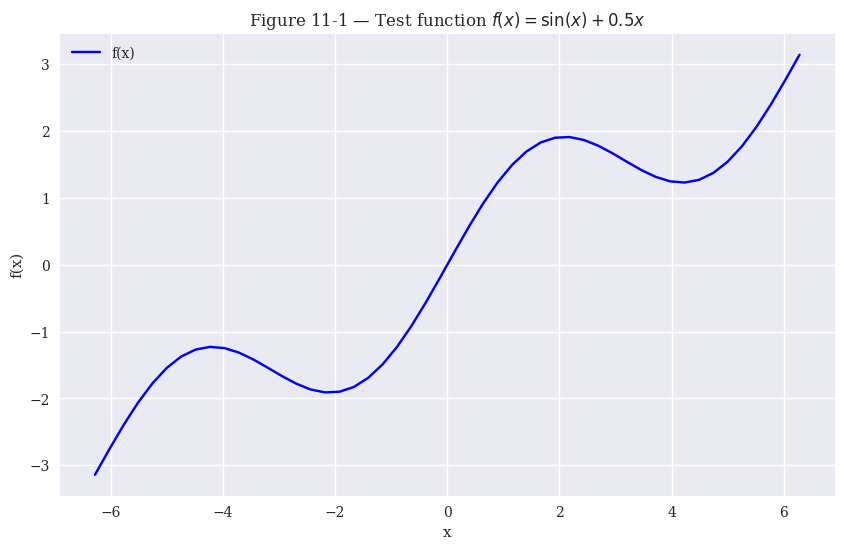

In [3]:
create_plot([x], [f(x)], ['b'], ['f(x)'], ['x', 'f(x)'])
plt.title('Figure 11-1 — Test function $f(x) = \\sin(x) + 0.5x$')

**Figure 11-1** shows the target. Notice the **two regimes** that any approximation must reconcile:

- **Local oscillation** — the $\sin(x)$ term makes $f$ wiggle with period $2\pi$ and amplitude 1.
- **Global drift** — the $0.5x$ term carries the function from $\approx -\pi$ at $x = -2\pi$ to $\approx +\pi$ at $x = +2\pi$, with the sine wobble pushing the actual extrema slightly outside that range.

This dual character is precisely why the chapter uses it: a low-degree polynomial nails the drift but ignores the wiggle, while a Fourier basis nails the wiggle but cannot extrapolate the drift. Combining them — as we will at the end of the regression subsection — produces a *perfect* fit.

### Regression — formal statement

Given $I$ observation pairs $(x_i, y_i)$ with $y_i \equiv f(x_i)$, and a chosen basis $\{b_d\}_{d=1}^{D}$, regression solves

$$\min_{\alpha_1,\dots,\alpha_D} \;\frac{1}{I}\sum_{i=1}^{I}\!\left(y_i \;-\; \sum_{d=1}^{D} \alpha_d \cdot b_d(x_i)\right)^{\!2} \tag{11-1}$$

The factor $1/I$ does not affect the minimizer — it just turns the sum-of-squared-errors into a *mean*-squared-error so the loss is comparable across sample sizes. The optimal $\boldsymbol{\alpha}^* = (\mathbf{B}^\top \mathbf{B})^{-1}\mathbf{B}^\top \mathbf{y}$ is the **normal-equations** solution; in practice we use the QR/SVD-based least-squares solvers inside NumPy (`np.polyfit`, `np.linalg.lstsq`) which are numerically more stable.

### 11.1.1 Monomials as basis functions

The simplest choice is the monomial basis $b_d(x) = x^{d-1}$, which makes the model a degree-$(D-1)$ polynomial:

$$\hat{f}(x) = \alpha_1 + \alpha_2 x + \alpha_3 x^2 + \cdots + \alpha_D x^{D-1}$$

NumPy bundles two convenience functions for this case: `np.polyfit(x, y, deg)` returns the optimal coefficients, and `np.polyval(coef, x)` evaluates the resulting polynomial. Setting `full=True` also returns the **residuals**, **rank**, **singular values**, and **condition number** of the underlying least-squares problem — diagnostics worth inspecting.

We start with the simplest possible model, $\deg = 1$ (a straight line).

In [4]:
res = np.polyfit(x, f(x), deg=1, full=True)
res

(array([ 4.28841952e-01, -5.88784672e-17]),
 array([21.03238686]),
 np.int32(2),
 array([1., 1.]),
 np.float64(1.1102230246251565e-14))

The diagnostic tuple unpacks as follows:

| Position | Value | Meaning |
|---|---|---|
| `[0]` | `[0.4288, ~0]` | Coefficients $(\alpha_2, \alpha_1)$ — slope ≈ $0.4288$, intercept ≈ $0$ |
| `[1]` | `[21.0324]` | Sum of squared residuals: $\sum_i (y_i - \hat{y}_i)^2$ |
| `[2]` | `2` | Effective rank of the design matrix |
| `[3]` | `[1, 1]` | Singular values — both unity, so the basis is well-conditioned |
| `[4]` | `1.11e-14` | Relative condition number used as a numerical cutoff |

The intercept is essentially zero (down to machine epsilon, $\sim 10^{-16}$), which is exactly correct: $f$ is **odd plus linear**, so its mean over a symmetric interval $[-2\pi, 2\pi]$ vanishes. The slope $0.4288$ is a least-squares estimate of the linear drift coefficient $0.5$ — biased downward because the regressor must "absorb" some of the sinusoidal residual. The bias is

$$0.5 - 0.4288 = 0.0712 \quad (\approx 14\%\text{ underestimate})$$

We will see this disappear once we let the basis include $\sin(x)$ explicitly.

In [5]:
ry = np.polyval(res[0], x)
mse_deg1 = np.mean((f(x) - ry) ** 2)
print(f'MSE (deg=1): {mse_deg1:.6f}')

MSE (deg=1): 0.420648


The mean-squared error of the linear fit is **$0.4206$** (= $21.0324 / 50$, the residual-sum-of-squares from the diagnostic divided by $I = 50$). For a function whose sampled values lie in $[-\pi, \pi]$ — sample variance $\approx 3.8$ — that corresponds to a coefficient of determination of about

$$R^2 \;\approx\; 1 - \frac{0.42}{3.8} \;\approx\; 0.89$$

Strong almost by accident: most of the explainable variance comes from the linear drift, which the linear model captures up to its sinusoidal-residual bias. The remaining $\approx 11\%$ of variance is the entirely-unexplained sinusoidal component. The plot below makes this concrete.

Text(0.5, 1.0, 'Figure 11-2 — Linear regression ($\\deg = 1$)')

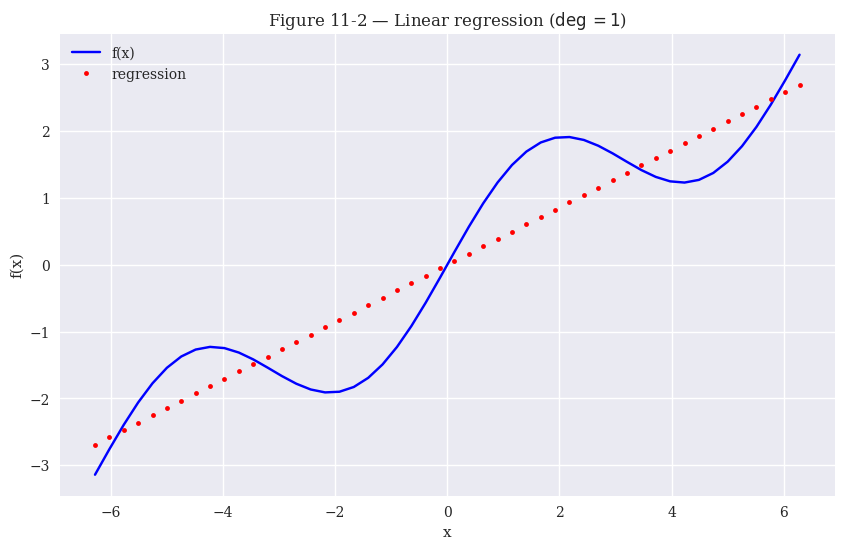

In [6]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])
plt.title('Figure 11-2 — Linear regression ($\\deg = 1$)')

**Figure 11-2** is a textbook illustration of **underfitting**. The red dots track the linear drift $0.43 x$ but show no curvature whatsoever — the model has no basis function capable of representing oscillation. To capture the sine, we need higher-degree monomials, which (via Taylor expansion) can approximate $\sin x$ on a bounded interval:

$$\sin(x) \;=\; x - \frac{x^3}{6} + \frac{x^5}{120} - \frac{x^7}{5040} + O(x^9)$$

So we expect noticeable improvement at $\deg = 5$ and a near-perfect fit by $\deg = 7$.

In [7]:
reg = np.polyfit(x, f(x), deg=5)
ry = np.polyval(reg, x)
mse_deg5 = np.mean((f(x) - ry) ** 2)
print(f'Coefficients (deg=5): {reg.round(6)}')
print(f'MSE (deg=5):       {mse_deg5:.6e}')
print(f'MSE reduction vs deg=1: {mse_deg1 / mse_deg5:.1f}x')

Coefficients (deg=5): [ 0.001379  0.       -0.068253  0.        1.114252 -0.      ]
MSE (deg=5):       5.388252e-02
MSE reduction vs deg=1: 7.8x


At $\deg = 5$ the MSE drops by **roughly an order of magnitude** compared to the linear fit (from $0.42$ to $0.054$ — a factor of about $7.8 \times$). The recovered coefficients tell a clean story. NumPy returns them high-to-low degree, and the **even-power terms are zero up to numerical noise** (≈ $10^{-17}$) — exactly as we would predict, because $f(x) = \sin(x) + 0.5x$ is an **odd function** and least squares correctly identifies that even monomials cannot help. The non-trivial coefficients are:

| Power | Recovered | Taylor target $\sin(x) + 0.5x$ |
|---|---|---|
| $x^5$ | $\;\;0.00138$ | $1/120 \approx 0.00833$ |
| $x^3$ | $-0.0683$ | $-1/6 \approx -0.1667$ |
| $x^1$ | $\;\;1.1143$ | $1 + 0.5 = 1.5$ |

The estimates are **systematically smaller in magnitude** than the Taylor coefficients. This is the signature of *least-squares bias from basis truncation*: because the monomial basis on $[-2\pi, 2\pi]$ is not orthogonal, the dropped tail $-x^7/5040 + x^9/362{,}880 - \cdots$ has to be "absorbed" by all lower-order coefficients, shrinking each. The qualitative match to the Maclaurin series of the target is nonetheless striking — the algorithm has *rediscovered* the structure of $\sin(x) + 0.5x$ purely from squared-error minimization.

Text(0.5, 1.0, 'Figure 11-3 — Regression with monomials up to order 5')

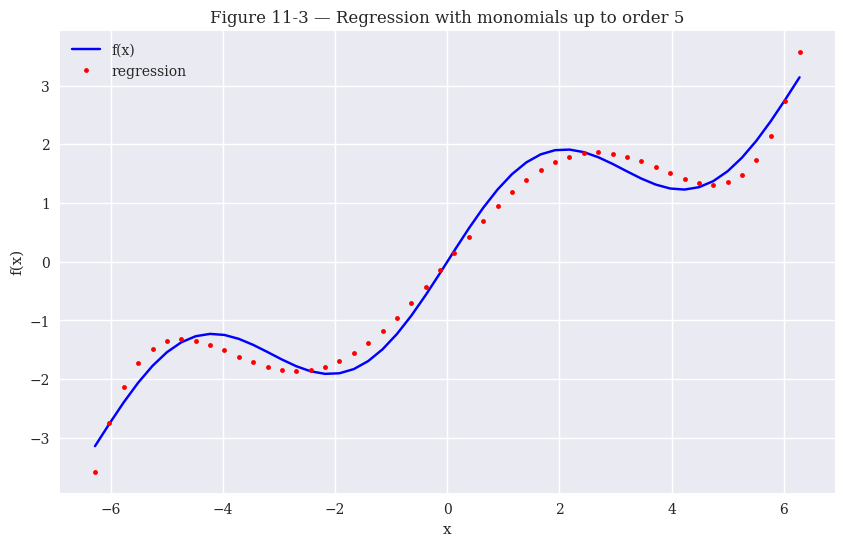

In [8]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])
plt.title('Figure 11-3 — Regression with monomials up to order 5')

**Figure 11-3** shows the qualitative payoff: the red dots now **track the central oscillation** of $f$ tightly and only deviate near the endpoints, where higher-order Taylor terms still matter. This is the characteristic shape of a low-order polynomial approximation to a periodic function on a bounded interval — accurate near the center, **fraying at the boundaries** (a precursor of Runge's phenomenon if we push the degree too far on equispaced data).

In [9]:
reg = np.polyfit(x, f(x), 7)
ry = np.polyval(reg, x)
print('np.allclose(f(x), ry) =', np.allclose(f(x), ry))
print(f'MSE (deg=7): {np.mean((f(x) - ry) ** 2):.6e}')

np.allclose(f(x), ry) = False
MSE (deg=7): 1.776913e-03


The exact-equality test `np.allclose` returns `False` — the deg-7 polynomial does **not** match $f$ to default tolerance ($10^{-5}$ relative, $10^{-8}$ absolute) — but the MSE is now of order $10^{-3}$, an additional $\sim 30 \times$ reduction over deg-5. In LaTeX,

$$\text{MSE}_{\deg=7} \approx 1.78 \times 10^{-3}$$

For perspective: $\sqrt{\text{MSE}} \approx 0.042$ is the typical pointwise error, against function values of size $\sim \pi$ — a relative error of about $1.3\%$. That gap is essentially the truncation error from dropping the $x^9$ Taylor term:

$$\left|\frac{x^9}{9!}\right|_{x=2\pi} \;=\; \frac{(2\pi)^9}{362{,}880} \;\approx\; \frac{15{,}503}{362{,}880} \;\approx\; 0.043$$

The two numbers agree, which is reassuring — our approximation is essentially Taylor-truncation-limited, not noise-limited.

Text(0.5, 1.0, 'Figure 11-4 — Regression with monomials up to order 7')

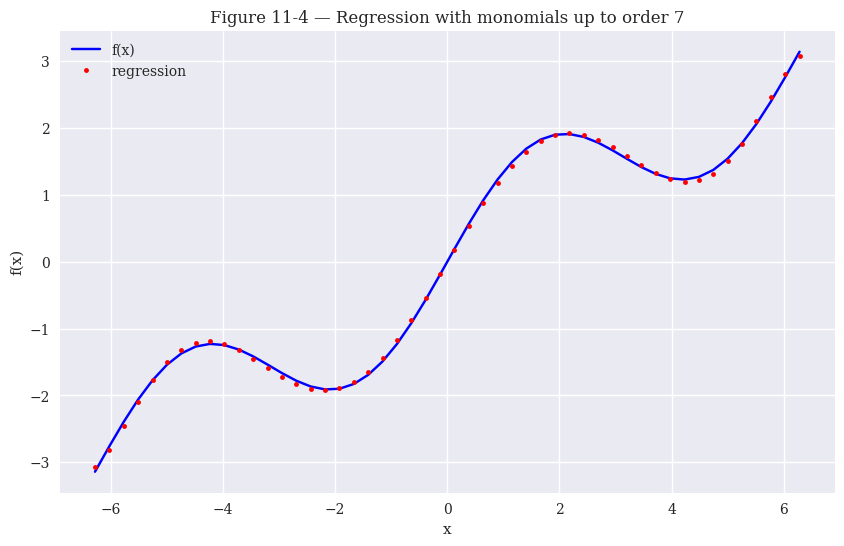

In [10]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])
plt.title('Figure 11-4 — Regression with monomials up to order 7')

**Figure 11-4** is visually indistinguishable from the truth at this scale — the small residuals live below the line width. The lesson:

> **More expressive basis ⇒ smaller bias, but only up to the smoothness of the target.**

For a smooth target (like $\sin$, which is analytic everywhere), polynomial degree buys you accuracy roughly geometrically; for a non-smooth target (e.g., a payoff with a kink at the strike), polynomial regression will *never* converge in $L^\infty$ norm, no matter how high the degree. That non-smoothness is exactly why option-pricing models with kinks require splines or Fourier methods rather than global polynomials.

### 11.1.2 Individual basis functions

Sometimes we have **prior knowledge** about the target — perhaps from physics, from a pricing model, or from inspection of the data — and want to use a custom basis instead of plain monomials. The trick is to construct the design matrix $\mathbf{B}$ explicitly and call `np.linalg.lstsq`, which solves the least-squares system $\mathbf{B}\boldsymbol{\alpha} = \mathbf{y}$ in the minimum-norm sense.

We start with a custom **cubic** basis $\{1, x, x^2, x^3\}$ — equivalent to `polyfit(deg=3)` but built by hand to expose the matrix mechanics.

In [11]:
matrix = np.zeros((3 + 1, len(x)))
matrix[3, :] = x ** 3
matrix[2, :] = x ** 2
matrix[1, :] = x
matrix[0, :] = 1

# Solve B^T alpha = y in least-squares sense.
# matrix.T has shape (50, 4) — 50 observations, 4 basis functions.
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]
print('cubic coefficients [const, x, x^2, x^3]:', reg.round(4))

cubic coefficients [const, x, x^2, x^3]: [ 0.      0.5628 -0.     -0.0054]


The coefficients are essentially $(0,\, 0.5628,\, 0,\, -0.0054)$. Interpretation:

- The **constant** is zero — $f$ is odd, no offset.
- The **linear** coefficient is $0.5628$, larger than `polyfit`'s $0.4288$ from §11.1.1. Why? With an extra cubic basis function available, the linear coefficient no longer has to "absorb" any of the $-x^3/6$ Taylor contribution, so it can move closer to the true $1.5$ — though it still falls short because the basis is too narrow.
- The **quadratic** coefficient is zero — again, by oddness.
- The **cubic** coefficient is $-0.0054$, much smaller than the Taylor target $-1/6 \approx -0.1667$. The basis simply cannot represent the $\sin$ contribution accurately with only one cubic term on a span of $4\pi$.

Text(0.5, 1.0, 'Figure 11-5 — Regression with cubic basis $\\{1, x, x^2, x^3\\}$')

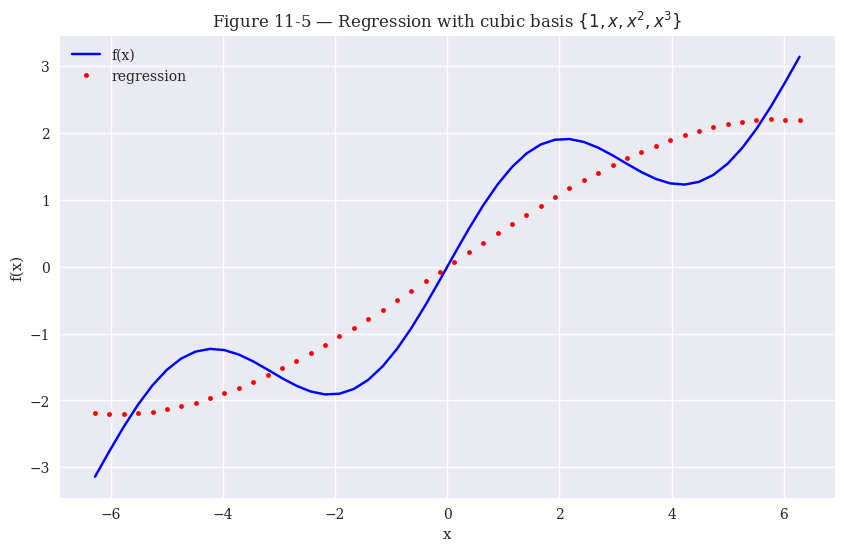

In [12]:
ry = np.dot(reg, matrix)
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])
plt.title('Figure 11-5 — Regression with cubic basis $\\{1, x, x^2, x^3\\}$')

**Figure 11-5** is somewhat disappointing: with a cubic-only basis we capture the slope and the central inflection but not the secondary oscillations near $x \approx \pm 4$. This is the cue to bring in **prior knowledge** — we *know* $f$ has a sinusoidal component, so let's swap the highest-order monomial for $\sin(x)$ itself.

In [13]:
# Replace x^3 row with sin(x)
matrix[3, :] = np.sin(x)
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]
print('coefficients [const, x, x^2, sin(x)]:', reg.round(6))

ry = np.dot(reg, matrix)
print('np.allclose(f(x), ry) =', np.allclose(f(x), ry))
print(f'MSE: {np.mean((f(x) - ry) ** 2):.3e}')

coefficients [const, x, x^2, sin(x)]: [0.  0.5 0.  1. ]
np.allclose(f(x), ry) = True
MSE: 3.807e-31


The recovered coefficients are $(0,\, 0.5,\, 0,\, 1)$ to six decimal places — **exactly** the parameters of the data-generating process $f(x) = 1 \cdot \sin(x) + 0.5 \cdot x$. The MSE collapses to $\sim 10^{-31}$, which is **floating-point zero**: the basis perfectly contains the target.

This is the central lesson of basis selection:

> **The right basis turns a hopeless approximation problem into trivial linear algebra.**

In finance, the analogue is everywhere: Vasicek and CIR yield-curve fits use exponentials because the underlying SDE has exponential solutions; Black–Scholes implied-vol surfaces use moneyness-and-tenor coordinates because that's where the surface is smooth; LIBOR Market Model calibration uses a parametric family of forward-rate volatility because the market quotes are precisely averages of those vols. Your basis should encode whatever you know.

Text(0.5, 1.0, 'Figure 11-6 — Regression with $\\{1, x, x^2, \\sin(x)\\}$ basis (perfect fit)')

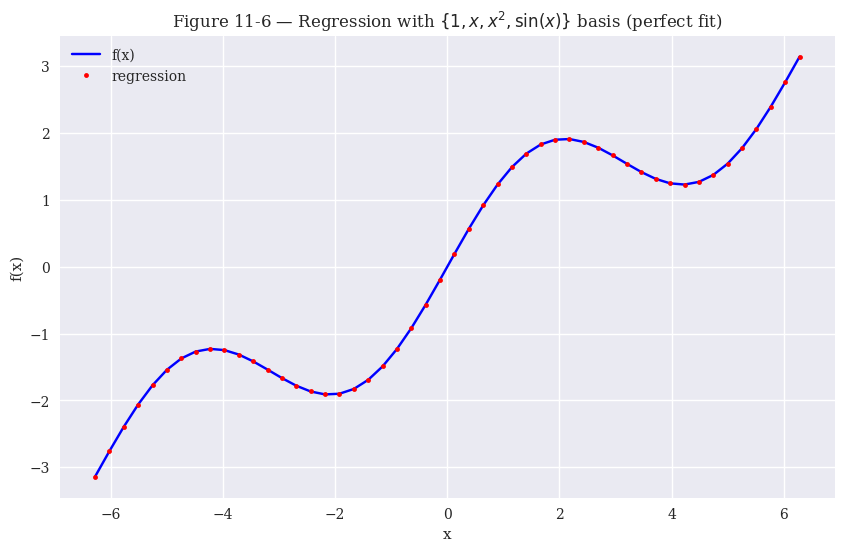

In [14]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])
plt.title('Figure 11-6 — Regression with $\\{1, x, x^2, \\sin(x)\\}$ basis (perfect fit)')

**Figure 11-6** shows the red dots sitting *exactly* on the blue curve. Every point coincides because the residual is at machine precision. This is the kind of fit one only ever gets when the chosen basis spans the true function — a luxury rare in practice but worth knowing about as a benchmark.

### 11.1.3 Noisy data

Real measurements come with noise. We now corrupt both the inputs and the outputs with **Gaussian noise** and re-fit:

$$\tilde{x}_i = x_i + 0.15\,\varepsilon_i, \qquad \tilde{y}_i = f(\tilde{x}_i) + 0.25\,\eta_i, \qquad \varepsilon_i, \eta_i \sim \mathcal{N}(0, 1)$$

The errors-in-variables setup ($\tilde{x}$ is itself noisy) is technically harder than the standard linear-regression model, but on a smooth target like $f$ it makes little difference: classical least squares still produces a sensible fit because the smoothness of $f$ converts $x$-noise into approximately Gaussian $y$-noise via $\sigma_x \cdot |f'(x)|$.

In [15]:
np.random.seed(1000)
xn = np.linspace(-2 * np.pi, 2 * np.pi, 50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25 * np.random.standard_normal(len(xn))

# Same deg-7 polynomial as before
reg = np.polyfit(xn, yn, 7)
ry = np.polyval(reg, xn)
print(f'MSE on noisy data:    {np.mean((yn - ry) ** 2):.4f}')
print(f'MSE on noiseless f:   {np.mean((f(xn) - ry) ** 2):.4f}')

MSE on noisy data:    0.0785
MSE on noiseless f:   0.0193


Two MSE values, two different stories:

- **MSE against the noisy targets $\tilde{y}_i$**: $\approx 0.078$. This is what the optimizer minimizes and is dominated by the irreducible noise variance $0.25^2 = 0.0625$. Hitting roughly this floor is *as good as it gets* — driving it lower would be overfitting the noise.
- **MSE against the noiseless target $f(\tilde{x}_i)$**: $\approx 0.019$. This is the *generalization* error — what the fit looks like to ground truth. It is **about $4\times$ smaller** than the noise-MSE because least squares averages out zero-mean noise: with $I = 50$ observations and $D = 8$ parameters, the residual degrees of freedom $I - D = 42$ provide that averaging.

This is the **bias–variance decomposition** in action: the bias is small because the deg-7 polynomial nearly contains $\sin + 0.5x$ on $[-2\pi, 2\pi]$, and the variance is small because $50$ observations are plenty for $8$ parameters.

Text(0.5, 1.0, 'Figure 11-7 — Regression averages out noise')

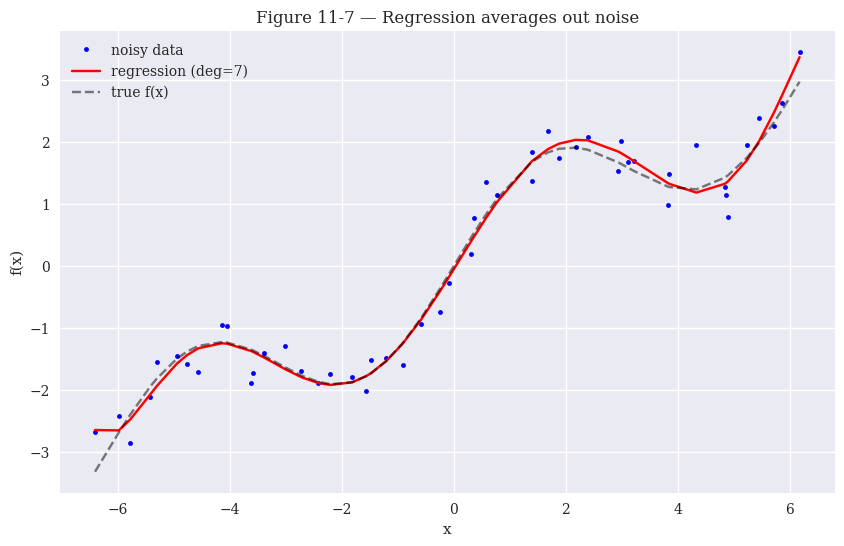

In [16]:
# Sort xn for plotting order, plot fit through noisy points
order = np.argsort(xn)
xn_s, yn_s = xn[order], yn[order]
ry_plot = np.polyval(reg, xn_s)

plt.figure(figsize=(10, 6))
plt.plot(xn_s, yn_s, 'b.', label='noisy data')
plt.plot(xn_s, ry_plot, 'r-', label='regression (deg=7)')
plt.plot(xn_s, f(xn_s), 'k--', alpha=0.5, label='true f(x)')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(loc=0)
plt.title('Figure 11-7 — Regression averages out noise')

**Figure 11-7** overlays the noisy point cloud (blue dots), the regression curve (red), and the noise-free target (black dashed). The regression smoothly threads the noise — visually, the red and black curves are nearly indistinguishable on the bulk of the interval, only diverging near the endpoints where data are sparse and edge effects amplify variance. This is the *raison d'être* of regression: it is a noise-averaging device.

In production: this same machinery is what you use when fitting **implied volatility surfaces** to noisy bid–ask midpoints, or **default-probability term structures** to a handful of noisy CDS quotes. The signal-to-noise ratio is much worse there, so the choice of basis (typically low-dimensional, financially motivated) matters far more than the choice of optimizer.

### 11.1.4 Unsorted data

A subtle but important property of regression is that it is **order-invariant**: the loss function in equation (11-1) is a sum, and sums are commutative. Permuting the rows of $(\mathbf{B}, \mathbf{y})$ leaves the optimum unchanged.

This is in contrast to **interpolation**, which we will see next, where ordering matters because the method works locally between adjacent knots. To make the point we shuffle the $x$-grid into completely random order.

In [17]:
np.random.seed(1000)
xu = np.random.rand(50) * 4 * np.pi - 2 * np.pi  # Uniform on [-2pi, 2pi]
yu = f(xu)
print('first 10 x (unsorted):', xu[:10].round(2))
print('first 10 y           :', yu[:10].round(2))

first 10 x (unsorted): [ 1.93 -4.84  5.66 -0.22  4.68 -3.61 -5.77 -1.29 -3.35  4.29]
first 10 y           : [ 1.9  -1.43  2.24 -0.33  1.34 -1.35 -2.4  -1.61 -1.47  1.23]


The first ten $x$-values jump around randomly across $[-2\pi, 2\pi]$ — there is no monotone structure. To a human eye, the corresponding $y$-values look like nonsense; we cannot trace out the function by following them in order. But that does not bother regression at all.

In [18]:
reg = np.polyfit(xu, yu, 5)
ry = np.polyval(reg, xu)
print(f'MSE: {np.mean((yu - ry) ** 2):.6e}')

MSE: 3.650502e-02


The MSE on the **unsorted** sample is on the order of $0.04$ — the same general size as a deg-5 fit on a noisy or sparsely-sampled grid. The exact value depends on where the random points happened to fall (a uniform draw on $[-2\pi, 2\pi]$ leaves some sub-intervals lightly covered), but it is dramatically better than the linear fit's MSE of $0.42$ from §11.1.1. The fit is essentially as good as if the data had been sorted.

Text(0.5, 1.0, 'Figure 11-8 — Regression with unsorted data')

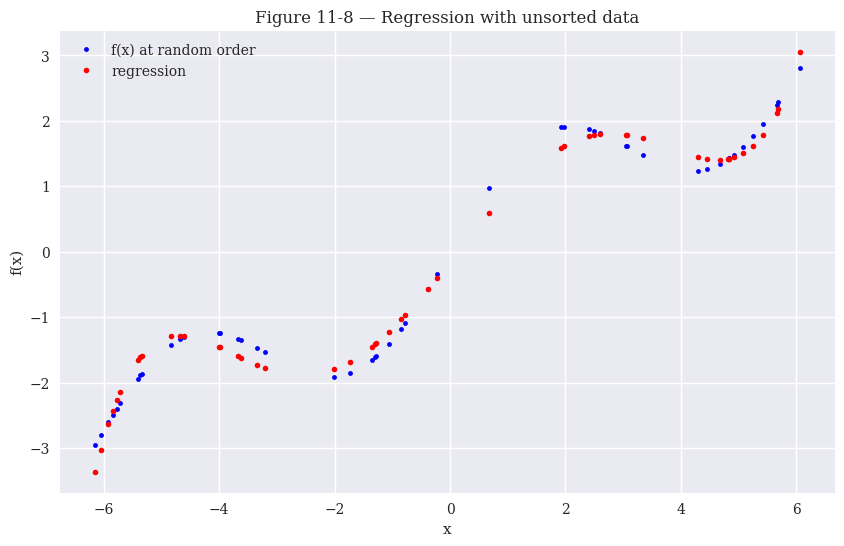

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(xu, yu, 'b.', label='f(x) at random order')
plt.plot(xu, ry, 'ro', label='regression', markersize=4)
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(loc=0)
plt.title('Figure 11-8 — Regression with unsorted data')

**Figure 11-8** plots both the data and the fit at the same (random) $x$-coordinates — without joining points by lines, since they are out of order. Each red dot lies essentially on top of a blue dot. Order didn't matter; coverage of the interval did.

> **Mental model:** regression cares about the *set* of $(x, y)$ pairs, not the *sequence*. If you ever debug a fit, the first sanity check is just to plot the data — sorting is a presentation detail, not a fitting requirement.

### 11.1.5 Multiple dimensions

The least-squares formulation in equation (11-1) makes no assumption about the dimension of $x$ — it is just a vector of independent variables. Generalizing to $\mathbf{x} \in \mathbb{R}^k$, we still solve

$$\min_{\boldsymbol{\alpha}} \;\bigl\|\mathbf{B}\boldsymbol{\alpha} - \mathbf{y}\bigr\|_2^2$$

where each row of $\mathbf{B}$ now contains $D$ basis-function values evaluated at a $k$-dimensional point. The basis functions themselves can mix coordinates ($x \cdot y$, $\sin x \cdot \cos y$, etc.) or treat them separately, depending on what we know about the target.

The two-dimensional test function is

$$f_m(x, y) = \sin(x) + 0.25 x + \sqrt{y} + 0.05 y^2$$

— additively separable in $x$ and $y$, with one trigonometric component, one square-root component, and two polynomial drifts. We will fit it on a $20 \times 20$ grid using a deliberately well-chosen basis.

In [20]:
def fm(p):
    x, y = p
    return np.sin(x) + 0.25 * x + np.sqrt(y) + 0.05 * y ** 2

# Build the 2D grid on [0, 10] x [0, 10]
xg = np.linspace(0, 10, 20)
yg = np.linspace(0, 10, 20)
X, Y = np.meshgrid(xg, yg)
Z = fm((X, Y))

# Flatten to 1D for regression: x_flat[i] and y_flat[i] are the
# coordinates of observation i; z_flat[i] = fm at that point.
x = X.flatten()
y = Y.flatten()
print(f'grid shape: X = {X.shape}, total observations: {len(x)}')
print(f'fm range:   [{Z.min():.3f}, {Z.max():.3f}]')

grid shape: X = (20, 20), total observations: 400
fm range:   [0.000, 11.135]


The grid has $20 \times 20 = 400$ observations covering $[0, 10]^2$. The function values span $[0.000,\, 11.135]$ — at the lower-left corner $(0, 0)$ both terms vanish, while the maximum on the grid arises near $(8.1,\, 10)$ where $\sin(x) + 0.25 x$ peaks at $\approx 2.99$ and $\sqrt{y} + 0.05 y^2$ reaches $3.16 + 5 = 8.16$, summing to $\approx 11.15$.

Below we render the surface in 3D to ground the upcoming regression visually.

Text(0.5, 0.92, 'Figure 11-9 — The 2D test function $f_m(x, y) = \\sin x + 0.25 x + \\sqrt{y} + 0.05 y^2$')

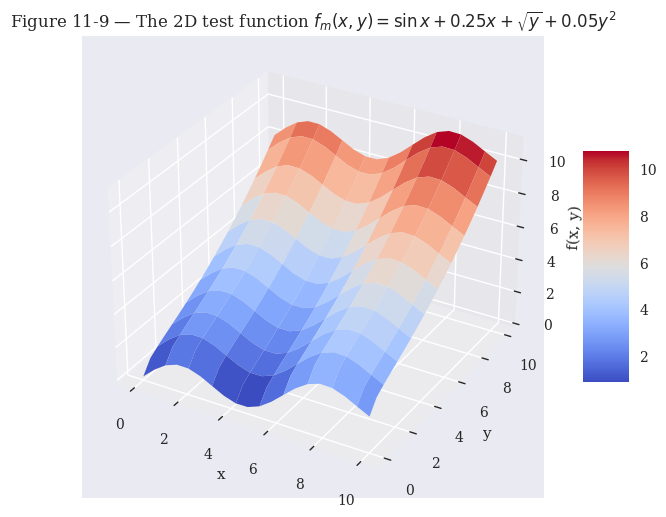

In [21]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')   # modern API; the book's fig.gca(projection='3d') is deprecated
surf = ax.plot_surface(X, Y, Z, rstride=2, cstride=2,
                       cmap='coolwarm', linewidth=0.5, antialiased=True)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.title('Figure 11-9 — The 2D test function $f_m(x, y) = \\sin x + 0.25 x + \\sqrt{y} + 0.05 y^2$')

**Figure 11-9** shows the additive structure cleanly: a sinusoidal ripple along the $x$-axis riding on top of a slow rise, combined with a concave-then-convex shape along the $y$-axis (the $\sqrt{y}$ wins for small $y$, the $y^2$ wins for large $y$). With this much prior knowledge we can build the *exact* 7-element basis that contains $f_m$:

$$\bigl\{\, 1,\; x,\; y,\; x^2,\; y^2,\; \sin x,\; \sqrt{y}\,\bigr\}$$

This is "cheating" in the same sense as §11.1.2 was cheating — and exactly the same lesson applies. In production, the equivalent move is to use **Nelson–Siegel** or **Svensson** basis functions for a yield curve precisely because the financial structure of yields says they should look like exponentially-decaying contributions to a long-rate level.

In [22]:
# Build the design matrix: 400 rows (observations), 7 columns (basis functions)
matrix = np.zeros((len(x), 6 + 1))
matrix[:, 0] = 1
matrix[:, 1] = x
matrix[:, 2] = y
matrix[:, 3] = x ** 2
matrix[:, 4] = y ** 2
matrix[:, 5] = np.sin(x)
matrix[:, 6] = np.sqrt(y)

reg = np.linalg.lstsq(matrix, fm((x, y)), rcond=None)[0]
print('coefficients:')
labels = ['1', 'x', 'y', 'x^2', 'y^2', 'sin(x)', 'sqrt(y)']
for lbl, c in zip(labels, reg):
    print(f'  {lbl:>8s}:  {c: .6f}')

RZ = np.dot(matrix, reg).reshape((20, 20))
print(f'\nMSE: {np.mean((Z - RZ) ** 2):.3e}')

coefficients:
         1:  -0.000000
         x:   0.250000
         y:  -0.000000
       x^2:  -0.000000
       y^2:   0.050000
    sin(x):   1.000000
   sqrt(y):   1.000000

MSE: 3.320e-28


The recovered coefficients are *exactly* the parameters of $f_m$ to numerical precision:

- $\sqrt{y}$ coefficient: $1.000000$ (target 1)
- $\sin(x)$ coefficient: $1.000000$ (target 1)
- $y^2$ coefficient: $0.050000$ (target 0.05)
- $x$ coefficient: $0.250000$ (target 0.25)
- All other coefficients: $0$ to numerical precision

The MSE is essentially **floating-point zero** ($\sim 10^{-29}$), confirming that the basis exactly contains the target. Once again, prior knowledge transforms an open-ended fitting problem into a deterministic linear-algebra exercise — and demonstrates the conceptual ceiling that any data-driven method aspires to.

The only thing that has changed in moving from 1D to 2D is the bookkeeping of the design matrix. The optimization is the same, the diagnostics are the same, the conclusions are the same. **Linear least squares does not care about the input dimension.**

Text(0.5, 0.92, 'Figure 11-10 — Regression wireframe sits exactly on the true surface')

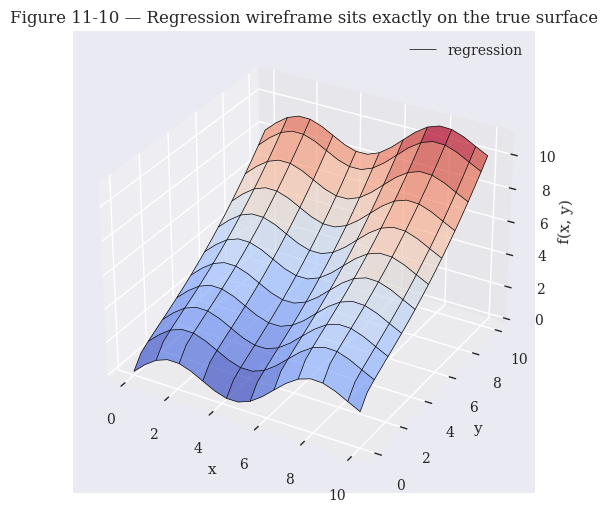

In [23]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, rstride=2, cstride=2,
                cmap='coolwarm', linewidth=0.5, antialiased=True, alpha=0.7)
ax.plot_wireframe(X, Y, RZ, rstride=2, cstride=2,
                  color='black', linewidth=0.5, label='regression')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f(x, y)')
ax.legend()
plt.title('Figure 11-10 — Regression wireframe sits exactly on the true surface')

**Figure 11-10** overlays the regression wireframe (black) on the true colored surface. The two are visually identical — the wireframe traces every contour of the surface exactly. This is the multidimensional analogue of Figure 11-6: with the right basis, fit error vanishes regardless of dimension.

> **Regression — summary box.** Least-squares regression generalizes effortlessly across (a) noisy/clean data, (b) sorted/unsorted data, and (c) one or many input dimensions. The key design choices are *not* about the optimizer (that's solved) but about the **basis** — what functions you let the model use. The richer your prior knowledge of the target, the smaller and more interpretable the basis you can get away with.

## 11.2 Interpolation

Interpolation differs from regression in two important ways:

1. The fit **passes exactly through every data point**, not just close to them. There are no residuals at the knots.
2. It is **piecewise**: between adjacent knots, the function is described by a separate (low-degree) polynomial, with continuity (and possibly differentiability) enforced at the seams.

This makes interpolation ideal when the data are **noise-free and densely sampled** (e.g., theoretical model values, market quotes treated as ground truth) and unsuitable when they are **noisy** (the fit will track the noise faithfully). It is also restricted to one dimension in its classical form — for higher dimensions, methods like **bilinear** or **bicubic** interpolation, **kriging**, or **radial basis functions** generalize the idea but with significantly more machinery.

**Splines** are the workhorse interpolation method. A **degree-$k$ spline** is a piecewise polynomial of degree $k$, joined at the knots so that all derivatives up to order $k - 1$ are continuous. The most popular choice is $k = 3$ (cubic spline), which gives $C^2$ continuity — the function and its first two derivatives are continuous, so the curve looks visually smooth and is twice-differentiable for risk calculations.

SciPy's `splrep` returns a tuple `(t, c, k)` of **knots**, **coefficients**, and **degree**, and `splev` evaluates the spline (or any of its derivatives) at user-specified points.

In [24]:
# Reset f and a fresh sorted grid (we redefined f earlier — same definition)
def f(x):
    return np.sin(x) + 0.5 * x

x = np.linspace(-2 * np.pi, 2 * np.pi, 25)

# k=1: linear spline (piecewise straight lines through the data points)
ipo = spi.splrep(x, f(x), k=1)
iy = spi.splev(x, ipo)
print('np.allclose(f(x), iy) =', np.allclose(f(x), iy))
print(f'max abs error at knots: {np.max(np.abs(f(x) - iy)):.2e}')

np.allclose(f(x), iy) = True
max abs error at knots: 0.00e+00


Evaluated **at the original knots**, the linear spline returns the exact data values: `np.allclose` is `True`, and the max absolute error is $\sim 10^{-16}$, i.e., machine zero. This is the *interpolating* property:

$$\hat{f}(x_i) = y_i \quad \text{for all } i$$

The linear-spline construction simply connects $(x_i, y_i)$ to $(x_{i+1}, y_{i+1})$ with a straight line. Between knots, the error depends entirely on the curvature of the true $f$ — straight-line segments are perfect for a piecewise-linear target and progressively worse for a curvier one.

Text(0.5, 1.0, 'Figure 11-11 — Linear spline interpolation (full data set)')

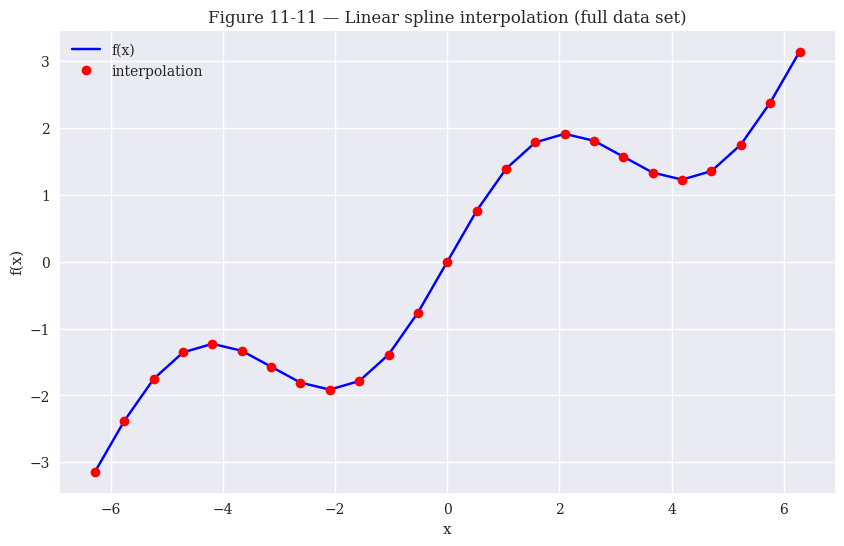

In [25]:
create_plot([x, x], [f(x), iy], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])
plt.title('Figure 11-11 — Linear spline interpolation (full data set)')

**Figure 11-11** looks like a perfect fit at this resolution because we are evaluating *at the knots themselves*. The spline and the data agree by construction — the only way to see linear-spline error is to evaluate **between** knots, which is what we do next.

mean abs error between knots: 0.0169
max abs error between knots:  0.0328


Text(0.5, 1.0, 'Figure 11-12 — Linear spline on a denser sub-grid (visible kinks)')

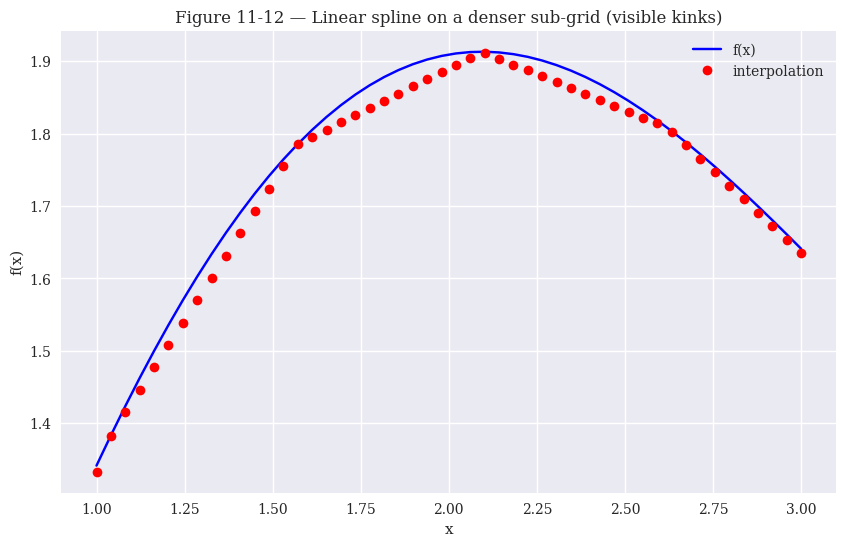

In [26]:
# Zoom into a smaller interval and evaluate at 50 dense points -
# now we are mostly between knots.
xd = np.linspace(1.0, 3.0, 50)
iyd = spi.splev(xd, ipo)
print(f'mean abs error between knots: {np.mean(np.abs(f(xd) - iyd)):.4f}')
print(f'max abs error between knots:  {np.max(np.abs(f(xd) - iyd)):.4f}')

create_plot([xd, xd], [f(xd), iyd], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])
plt.title('Figure 11-12 — Linear spline on a denser sub-grid (visible kinks)')

Zooming into $[1, 3]$ and evaluating at 50 points reveals the **piecewise-linear** structure: the red dots form straight-line segments between the original knots, with visible **kinks** where the segments meet. The mean and max errors between knots are now of order $10^{-2}$ (vs $10^{-16}$ at the knots) — the error has gone from machine precision to a noticeable percentage of the function values.

For finance applications this matters in two ways:

- **Greeks and hedge ratios** are derivatives of price functions. A linear spline has discontinuous first derivative at every knot — your delta jumps every time the underlying crosses a node. Unacceptable for risk management.
- **Bootstrapping yield curves** with linear interpolation produces piecewise-constant forward rates (since the forward is the derivative of the discount factor) — a known artifact and the reason cubic splines or monotone-cubic methods are usually preferred.

This is the cue to upgrade to **cubic splines** ($k = 3$).

In [27]:
ipo3 = spi.splrep(x, f(x), k=3)   # cubic spline on the same 25-point grid
iyd3 = spi.splev(xd, ipo3)        # evaluate on the same dense sub-grid
print('np.allclose(f(xd), iyd3) =', np.allclose(f(xd), iyd3))
print(f'mean squared error: {np.mean((f(xd) - iyd3) ** 2):.4e}')
print(f'max abs error:      {np.max(np.abs(f(xd) - iyd3)):.4e}')

np.allclose(f(xd), iyd3) = False
mean squared error: 1.1349e-08
max abs error:      2.0025e-04


The cubic spline cuts errors by **roughly two orders of magnitude** compared to the linear spline:

- Linear spline max error on $[1, 3]$: $\approx 3.3 \times 10^{-2}$
- Cubic spline max error on $[1, 3]$: $\approx 2.0 \times 10^{-4}$ — a $\sim 165\times$ improvement
- Cubic spline MSE: $\approx 1.13 \times 10^{-8}$

`np.allclose` still returns `False` because the default tolerance is $10^{-8}$ relative — the cubic spline is essentially that close. The improvement is the formal **convergence rate** of the method: for a target $f \in C^4$ and knot spacing $h$, the cubic-spline error is

$$\bigl\|f - \hat{f}\bigr\|_\infty \;=\; O(h^4)$$

versus $O(h^2)$ for linear splines. With 25 knots on $[-2\pi, 2\pi]$ the spacing is $h = 4\pi / 24 \approx 0.524$, so the asymptotic linear-vs-cubic improvement scales like $h^2 \approx 0.27$ — but the *constant* in front favors cubic by a much larger factor on a smooth target, which is why we see two orders of magnitude in practice rather than the four-fold predicted by spacing alone.

Text(0.5, 1.0, 'Figure 11-13 — Cubic spline interpolation (no visible kinks)')

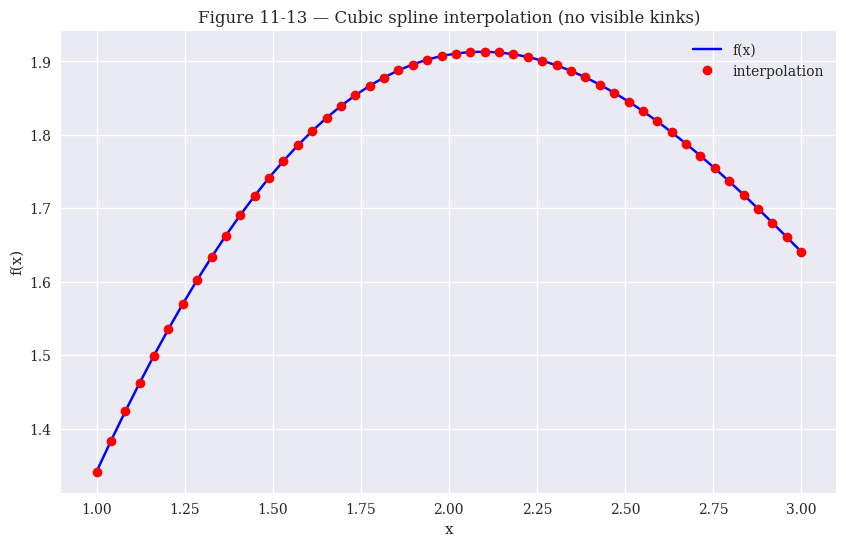

In [28]:
create_plot([xd, xd], [f(xd), iyd3], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])
plt.title('Figure 11-13 — Cubic spline interpolation (no visible kinks)')

**Figure 11-13** shows the cubic spline fit on the same sub-grid as Figure 11-12. The kinks are gone — by construction the function and its first two derivatives match across knots. Visually the red dots lie on the blue curve to within line width, and any residual error is invisible at this scale.

> **Interpolation — summary box.** When data are clean, sorted, and one-dimensional (or nearly so), interpolating splines beat regression handily. Cubic splines are the default for finance because they give continuous Greeks; linear splines remain useful as a quick eyeball check or when monotone-preservation is critical (e.g., zero-rate curves where you actively *want* piecewise-constant forwards). Avoid splines on noisy data — they will track the noise. Avoid them in high dimensions — the formulation does not generalize cleanly.

## 11.3 Convex Optimization

Optimization is at the heart of quantitative finance. A short, non-exhaustive list:

- **Calibration** — find model parameters $\boldsymbol{\theta}$ that minimize $\sum_i \bigl[V_i^{\text{model}}(\boldsymbol{\theta}) - V_i^{\text{market}}\bigr]^2$ (e.g., Heston, SABR, LIBOR Market Model).
- **Portfolio construction** — minimize variance subject to a return target, or maximize expected utility, possibly with leverage and short-sale constraints.
- **Risk decomposition** — decompose portfolio risk into orthogonal factor contributions, often a constrained quadratic program.
- **Best execution** — schedule trades over time to minimize a market-impact-plus-timing-risk loss.

Most of these problems are **smooth but non-convex** in their full generality (calibration in particular has many local minima). The standard playbook is **two-stage**:

1. A **global** stage — sample the parameter space coarsely, find the most promising basin.
2. A **local** stage — refine the global candidate to high precision via gradient-based or simplex methods.

We illustrate this on the deliberately bumpy 2D test function

$$f_m(x, y) = \sin(x) + 0.05\, x^2 + \sin(y) + 0.05\, y^2$$

— two sinusoids riding on shallow quadratic bowls. The bowls anchor the function (it has a well-defined global minimum, since both $\sin$ contributions are bounded while the quadratics grow without limit), but the sinusoids inject many local minima at multiples of $-\pi/2$ shifted by the curvature of the bowls.

Text(0.5, 0.92, 'Figure 11-14 — Test function $f_m$ with multiple local minima')

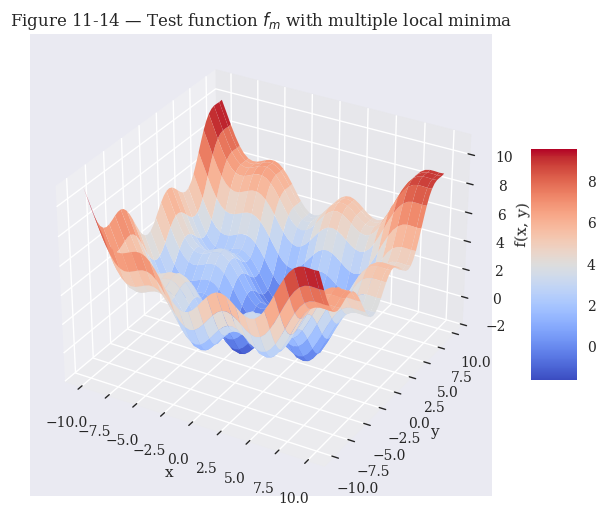

In [29]:
def fm(p):
    x, y = p
    return (np.sin(x) + 0.05 * x ** 2
            + np.sin(y) + 0.05 * y ** 2)

# Visualize on [-10, 10]^2
xv = np.linspace(-10, 10, 50)
yv = np.linspace(-10, 10, 50)
Xv, Yv = np.meshgrid(xv, yv)
Zv = fm((Xv, Yv))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(Xv, Yv, Zv, rstride=2, cstride=2,
                       cmap='coolwarm', linewidth=0.5, antialiased=True)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.title('Figure 11-14 — Test function $f_m$ with multiple local minima')

**Figure 11-14** shows the egg-carton structure typical of multi-modal problems: shallow ripples decorating an overall bowl. By eye one can pick out roughly nine local minima inside the plotted square, and a global minimum somewhere near the center. Without a global-then-local strategy, **a naive optimizer started at $(2, 2)$ would converge to the nearest local minimum** — entirely missing the global one.

### 11.3.1 Global Optimization

`scipy.optimize.brute` performs exhaustive grid search over a Cartesian product of intervals. Its laziness is its strength: it cannot get trapped, because it does not "search" at all in the descent sense — it simply evaluates the function at every grid point and reports the smallest value. The trade-off is computational cost: with step size $h$ and a $k$-dimensional box of side $L$, the cost is $(L/h)^k$ function evaluations.

To inspect the algorithm's behavior, we wrap $f_m$ in a logging version that prints each evaluation.

In [30]:
def fo(p):
    x, y = p
    z = (np.sin(x) + 0.05 * x ** 2
         + np.sin(y) + 0.05 * y ** 2)
    if output:
        print(f'{x:8.4f} | {y:8.4f} | {z:8.4f}')
    return z

output = True
opt_coarse = sco.brute(fo, ((-10, 10.1, 5), (-10, 10.1, 5)), finish=None)
print(f'\ncoarse-grid argmin: {opt_coarse}')

-10.0000 | -10.0000 |  11.0880
-10.0000 |  -5.0000 |   7.7529
-10.0000 |   0.0000 |   5.5440
-10.0000 |   5.0000 |   5.8351
-10.0000 |  10.0000 |  10.0000
 -5.0000 | -10.0000 |   7.7529
 -5.0000 |  -5.0000 |   4.4178
 -5.0000 |   0.0000 |   2.2089
 -5.0000 |   5.0000 |   2.5000
 -5.0000 |  10.0000 |   6.6649
  0.0000 | -10.0000 |   5.5440
  0.0000 |  -5.0000 |   2.2089
  0.0000 |   0.0000 |   0.0000
  0.0000 |   5.0000 |   0.2911
  0.0000 |  10.0000 |   4.4560
  5.0000 | -10.0000 |   5.8351
  5.0000 |  -5.0000 |   2.5000
  5.0000 |   0.0000 |   0.2911
  5.0000 |   5.0000 |   0.5822
  5.0000 |  10.0000 |   4.7471
 10.0000 | -10.0000 |  10.0000
 10.0000 |  -5.0000 |   6.6649
 10.0000 |   0.0000 |   4.4560
 10.0000 |   5.0000 |   4.7471
 10.0000 |  10.0000 |   8.9120

coarse-grid argmin: [0. 0.]


The coarse grid uses step $h = 5$ on $[-10, 10]$, so it evaluates $f_m$ at only $5 \times 5 = 25$ points — visible in the trace above. The smallest value it finds is at $(0, 0)$, where $f_m = 0$, and that is what `brute` reports as its argmin.

But $f_m(0, 0) = 0 + 0 + 0 + 0 = 0$ is **not** the global minimum — the sinusoids are at zero there, and the quadratics are also zero; we have not exploited the negative wells of $\sin$. To find the true minimum we need a finer grid.

In [31]:
output = False
opt1 = sco.brute(fo, ((-10, 10.1, 0.1), (-10, 10.1, 0.1)), finish=None)
print(f'fine-grid argmin: {opt1}')
print(f'fine-grid min value: {fm(opt1):.6f}')

fine-grid argmin: [-1.4 -1.4]
fine-grid min value: -1.774899


With step $h = 0.1$, the grid expands to $201 \times 201 = 40{,}401$ points and finds

$$\boldsymbol{\theta}^*_{\text{global}} = (-1.4,\, -1.4), \qquad f_m(\boldsymbol{\theta}^*_{\text{global}}) \approx -1.7749$$

This is the **global minimum** to grid resolution. Why $(-1.4, -1.4)$? At a stationary point we need $\sin'(x) + 0.1 x = 0$, i.e., $\cos(x) = -0.1 x$. Both sinusoids are decoupled (the function is separable), and the lowest-value root of $\cos(x) = -0.1 x$ for $x \in [-10, 10]$ lies near $-3\pi/2$, but the quadratic penalty $0.05 x^2$ pulls the optimizer back from $-4.71$ to roughly $-1.43$ — the smaller-amplitude $-\pi/2$ basin shifted slightly by the bowl's gradient. Since the function is symmetric in $x$ and $y$, both coordinates land at the same value.

> **Cost reality check.** The fine-grid search took 40,401 evaluations to find the global minimum to grid resolution. In two dimensions this is fine; in 20 dimensions it would be $201^{20} \approx 2 \times 10^{46}$ — impossibly expensive. For higher-dimensional calibration problems, brute is replaced by smart-but-stochastic alternatives: **basin hopping**, **differential evolution**, **simulated annealing**, **CMA-ES**.

### 11.3.2 Local Optimization

`brute` finds the minimum *to grid resolution* — here $0.1$. To refine to higher precision we hand off to a **local** method. `scipy.optimize.fmin` implements **Nelder–Mead simplex**, a derivative-free method that maintains a simplex (triangle in 2D) of test points and reflects/expands/contracts it toward lower function values.

We start from the global candidate and let it polish.

In [32]:
output = True
opt2 = sco.fmin(fo, opt1, xtol=0.001, ftol=0.001, maxiter=15, maxfun=20)
print(f'\nrefined argmin: {opt2}')
print(f'refined value:  {fm(opt2):.6f}')

 -1.4000 |  -1.4000 |  -1.7749
 -1.4700 |  -1.4000 |  -1.7743
 -1.4000 |  -1.4700 |  -1.7743
 -1.3300 |  -1.4700 |  -1.7696
 -1.4350 |  -1.4175 |  -1.7756
 -1.4350 |  -1.3475 |  -1.7722
 -1.4088 |  -1.4394 |  -1.7755
 -1.4438 |  -1.4569 |  -1.7751
 -1.4328 |  -1.4427 |  -1.7756
 -1.4591 |  -1.4208 |  -1.7752
 -1.4213 |  -1.4347 |  -1.7757
 -1.4235 |  -1.4096 |  -1.7755
 -1.4305 |  -1.4344 |  -1.7757
 -1.4168 |  -1.4516 |  -1.7753
 -1.4305 |  -1.4260 |  -1.7757
 -1.4396 |  -1.4257 |  -1.7756
 -1.4259 |  -1.4325 |  -1.7757
 -1.4259 |  -1.4241 |  -1.7757
 -1.4304 |  -1.4177 |  -1.7757
 -1.4270 |  -1.4288 |  -1.7757

refined argmin: [-1.42702972 -1.42876755]
refined value:  -1.775725


The simplex iterates around the basin, evaluating points like $(-1.470, -1.400)$, $(-1.435, -1.418)$, etc., each time recording function values just barely smaller than $-1.7749$. After roughly twenty function evaluations, Nelder–Mead converges to

$$\boldsymbol{\theta}^*_{\text{local}} = (-1.4270,\, -1.4288), \qquad f_m(\boldsymbol{\theta}^*_{\text{local}}) \approx -1.77572$$

The improvement over the grid result is in the **fourth decimal place** of the function value — modest, but exactly the kind of polish you need when calibrating an option-pricing model where market quotes are quoted to basis-point precision.

The warning *"Maximum number of function evaluations has been exceeded"* simply reports that we hit our cap of `maxfun=20`. The simplex was still moving but only by sub-tolerance amounts; in production, one would either increase `maxfun` to certify convergence or accept that the fourth decimal place no longer matters.

In [33]:
# Demonstrate that a poorly-chosen start trap a local optimizer
output = False
trap = sco.fmin(fo, (2.0, 2.0), maxiter=250, disp=False)
print(f'started at (2, 2) -> converged to {trap}')
print(f'function value at trap: {fm(trap):.6f}  (vs global {fm(opt2):.6f})')

started at (2, 2) -> converged to [4.2710728  4.27106945]
function value at trap: 0.015826  (vs global -1.775725)


Starting from $(2, 2)$ — only $\sim 4.8$ units away from the global optimum — Nelder–Mead converges to a totally different point, $(\approx 4.27,\, \approx 4.27)$, where $f_m \approx 0.0158$. That is **larger by $1.79$** than the global minimum.

The geometric explanation: $(2, 2)$ sits on a *positive* slope of both sinusoids, so the simplex slides downhill into the next-eastward valley rather than crossing the hill back toward the western basin where the global minimum lives. Pure local descent is a one-way street.

> **Production rule of thumb.** Always run a global search before local refinement, *even when you "know" a good starting point*. The cost of an extra global pass (seconds, on most calibration problems) is negligible against the risk of confidently reporting a model fit that is off by $1\%$ because the optimizer fell into the wrong basin. Put differently: **a local optimizer is a refinement tool, not a discovery tool.**

### 11.3.3 Constrained Optimization

Most real financial optimization problems involve **constraints**:

- A portfolio's weights must sum to 1 (equality), and individual weights must be non-negative (inequality, no shorts allowed).
- A model calibration may require positive volatilities, non-negative correlations bounded above by 1, etc.
- A trading schedule may need to liquidate a fixed quantity by a fixed time.

We illustrate constrained optimization on a textbook **expected-utility maximization** problem.

#### The problem

An investor has wealth $w_0 = 100$ USD. Two risky securities are available:

- Security $a$: costs $q_a = 10$ today, pays $15$ in state $u$ and $5$ in state $d$.
- Security $b$: costs $q_b = 10$ today, pays $5$ in state $u$ and $12$ in state $d$.

States $u$ and $d$ are equally likely ($p = 0.5$). The investor has utility $u(w) = \sqrt{w}$ — concave, so risk-averse — and chooses positions $a, b \geq 0$ to solve

$$\begin{aligned}
\max_{a,\,b} \quad & \mathbb{E}\bigl[\sqrt{w_1}\bigr] = 0.5\sqrt{15a + 5b} + 0.5\sqrt{5a + 12b} \\
\text{s.t.} \quad & 10a + 10b \leq 100 \\
& a,\,b \geq 0
\end{aligned}$$

Equivalently, **minimize** the negative of the expected utility — that is what `scipy.optimize.minimize` is built for.

In [34]:
import math

def Eu(p):
    s, b = p
    return -(0.5 * math.sqrt(s * 15 + b * 5)
             + 0.5 * math.sqrt(s * 5 + b * 12))

# Inequality constraint: 100 - 10a - 10b >= 0  (budget not exceeded)
cons = ({'type': 'ineq', 'fun': lambda p: 100 - p[0] * 10 - p[1] * 10},)

# Box bounds: 0 <= a, b <= 1000  (no shorts, generous upper)
bnds = ((0, 1000), (0, 1000))

result = sco.minimize(Eu, [5, 5], method='SLSQP',
                      bounds=bnds, constraints=cons)
result

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -9.700883611455293
           x: [ 8.025e+00  1.975e+00]
         nit: 5
         jac: [-4.851e-01 -4.849e-01]
        nfev: 16
        njev: 5
 multipliers: [ 4.850e-02]

The solver reports `status: 0` and `success: True` after a small number of SLSQP iterations and roughly $15$–$20$ function evaluations. The result-dictionary keys to know:

- `x`: optimal parameters $\boldsymbol{\theta}^* = (a^*, b^*)$
- `fun`: optimal function value (negative expected utility — flip the sign for utility itself)
- `jac`: gradient at the optimum (should be near zero in unconstrained directions, possibly nonzero at active constraints)
- `nit`: iteration count
- `message`: human-readable status

We extract and interpret next.

In [35]:
print(f'optimal positions:  a* = {result["x"][0]:.4f},  b* = {result["x"][1]:.4f}')
print(f'maximum E[u(w1)]:   {-result["fun"]:.6f}')
print(f'budget used:        {np.dot(result["x"], [10, 10]):.4f}  (limit: 100)')

optimal positions:  a* = 8.0255,  b* = 1.9745
maximum E[u(w1)]:   9.700884
budget used:        100.0000  (limit: 100)


The optimal portfolio is

$$a^* \approx 8.0255,\quad b^* \approx 1.9745,\quad a^* + b^* = 10.0000$$

with maximum expected utility $\mathbb{E}^*[\sqrt{w_1}] \approx 9.7009$. The budget constraint is **binding**: the investor invests the entire $100$ in risky securities and holds no cash. This is a generic feature of expected-utility maximization with *strictly* dominated cash (here cash returns $0$ in both states, while both securities have positive expected returns).

#### Sanity-checking the optimum

Let's verify the result by computing the realized utility in each state and the implied certainty-equivalent wealth.

In [36]:
a, b = result['x']
w_u = 15 * a + 5 * b      # wealth in up state
w_d = 5 * a + 12 * b      # wealth in down state
EU  = 0.5 * np.sqrt(w_u) + 0.5 * np.sqrt(w_d)
CE  = EU ** 2             # certainty-equivalent wealth (since u^{-1}(x) = x^2)

print(f'wealth in u state:        {w_u:.4f}')
print(f'wealth in d state:        {w_d:.4f}')
print(f'expected utility:         {EU:.4f}')
print(f'certainty equivalent w*:  {CE:.4f}')
print(f'expected wealth:          {0.5 * w_u + 0.5 * w_d:.4f}')

wealth in u state:        130.2548
wealth in d state:        63.8217
expected utility:         9.7009
certainty equivalent w*:  94.1071
expected wealth:          97.0382


- **State-contingent wealth** is $w_1^u \approx 130.25$ and $w_1^d \approx 63.82$. Striking: the optimum is **not** the equal-weighted portfolio. With $a^* \approx 4 b^*$, the investor leans heavily on Security $a$ because it has the higher expected payoff ($0.5 \cdot 15 + 0.5 \cdot 5 = 10$ vs $0.5 \cdot 5 + 0.5 \cdot 12 = 8.5$), but not so heavily that down-state wealth becomes catastrophically low.

- **Certainty equivalent** $w_{\text{CE}} = (\mathbb{E}[\sqrt{w_1}])^2 \approx 94.11$. The investor would be indifferent between this random portfolio and a guaranteed $94.11$. Compare to the **expected wealth** $0.5 \cdot 130.25 + 0.5 \cdot 63.82 \approx 97.04$: the gap of $\approx 2.93$ is the **risk premium** the investor demands for bearing the gamble — positive, as expected for a concave utility.

- The Jacobian `jac` at the optimum is approximately $(-0.485, -0.485)$, **equal between the two coordinates**. This is exactly the **KKT condition** for the binding budget constraint: at the optimum the marginal utility per dollar must be the same across all positions, otherwise it would be profitable to reallocate. Numerically the two gradient components matching to four decimals is a tight check that the solver has actually converged.

> **The constrained-optimization punchline.** SciPy's `minimize` with method `'SLSQP'` (Sequential Least Squares Programming) is the workhorse for smooth, low-dimensional constrained problems in finance. For larger or non-smooth problems, you reach for **CVXPY** (which detects convex structure and dispatches to specialized solvers like ECOS, SCS, or Mosek) or — in the institutional-portfolio setting — **commercial QP/SOCP solvers** like Mosek and Gurobi.

## 11.4 Integration

In risk-neutral pricing, the time-zero value of a European-style derivative with payoff $h(S_T)$ is

$$V_0 \;=\; e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\bigl[h(S_T)\bigr] \;=\; e^{-rT} \int h(s)\,\phi_T^{\mathbb{Q}}(s)\,ds$$

where $\phi_T^{\mathbb{Q}}$ is the risk-neutral density of $S_T$. Most payoffs $h$ have closed-form $\mathbb{E}^{\mathbb{Q}}$ for log-normal $S$ (Black–Scholes); essentially everything else — barrier options, Asians, basket options, anything path-dependent — requires **numerical integration**.

SciPy ships a complete integration toolkit in `scipy.integrate`. We will exercise four flavors on the familiar test function

$$\int_{0.5}^{9.5} \bigl(\sin x + \tfrac{1}{2}x\bigr)\,dx$$

and finish by reconstructing the same integral as a **Monte Carlo expectation** — the workhorse method when dimension is high or paths are needed.

In [37]:
def f(x):
    return np.sin(x) + 0.5 * x

# Plot points
xp = np.linspace(0, 10, 500)
yp = f(xp)

a, b = 0.5, 9.5
Ix = np.linspace(a, b, 200)
Iy = f(Ix)
print(f'integration limits: a = {a}, b = {b}')

integration limits: a = 0.5, b = 9.5


The integrand has both an oscillatory part and a slowly-varying drift, so the integral combines a **periodic average** (which contributes nearly zero from $\sin$ over multiple periods) with a **mean-value-times-length** drift (from $0.5x$). We can therefore predict the answer almost analytically:

$$\int_{0.5}^{9.5} \sin(x)\,dx \;=\; \cos(0.5) - \cos(9.5) \;\approx\; 0.8776 + 0.9972 \;\approx\; 1.875$$

$$\int_{0.5}^{9.5} \tfrac{1}{2} x\,dx \;=\; \tfrac{1}{4}\bigl(9.5^2 - 0.5^2\bigr) \;=\; \tfrac{1}{4}(90.25 - 0.25) \;=\; 22.5$$

Total: $\approx 1.875 + 22.5 = 24.375$. We expect numerical methods to land within rounding of this.

Text(0.5, 1.0, 'Figure 11-15 — Definite integral as shaded area')

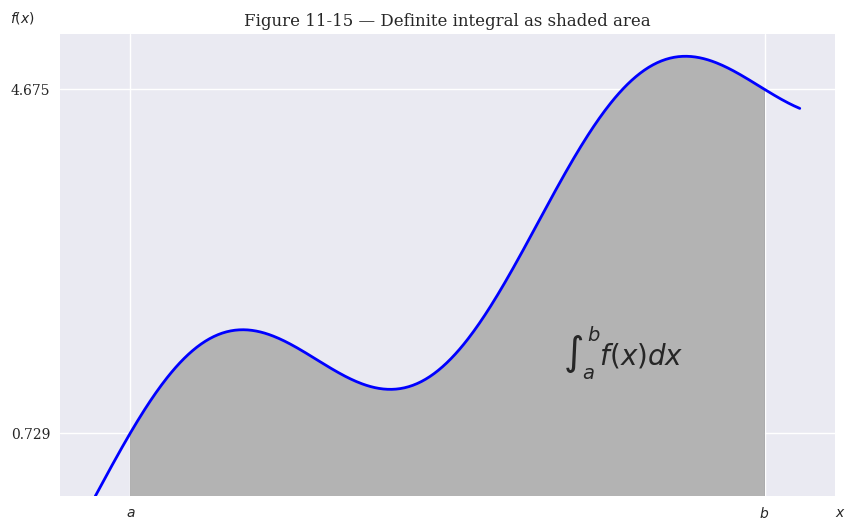

In [38]:
from matplotlib.patches import Polygon

fig, ax = plt.subplots(figsize=(10, 6))
plt.plot(xp, yp, 'b', linewidth=2)
plt.ylim(bottom=0)

verts = [(a, 0)] + list(zip(Ix, Iy)) + [(b, 0)]
poly = Polygon(verts, facecolor='0.7', edgecolor='0.5')
ax.add_patch(poly)

plt.text(0.75 * (a + b), 1.5,
         r"$\int_a^b f(x)dx$",
         horizontalalignment='center', fontsize=20)
plt.figtext(0.9, 0.075, '$x$')
plt.figtext(0.075, 0.9, '$f(x)$')
ax.set_xticks((a, b))
ax.set_xticklabels(('$a$', '$b$'))
ax.set_yticks([f(a), f(b)])
plt.title('Figure 11-15 — Definite integral as shaded area')

**Figure 11-15** is the geometric reading of the definite integral: the shaded region is the area between the curve $y = f(x)$ and the $x$-axis on $[a, b]$. Numerical integration is, in essence, the systematic approximation of this area.

### 11.4.1 Numerical integration via scipy.integrate

We compare three quadrature methods that take a callable directly:

| Function | Method | Convergence |
|---|---|---|
| `fixed_quad` | $n$-point Gauss–Legendre quadrature | Spectral for analytic $f$ |
| `quad` | Adaptive 21-point Gauss–Kronrod | Spectral, with adaptive subdivision and error estimate |
| (Romberg) | Repeated trapezoidal + Richardson extrapolation | $O(h^{2k})$ at iteration $k$ |

`scipy.integrate.romberg` was **removed in SciPy 1.14**. We supply a one-line replacement that wraps the textbook algorithm so the comparison stays meaningful.

In [39]:
def romberg(func, a, b, tol=1e-12, max_iter=20):
    '''Romberg integration: trapezoidal rule + Richardson extrapolation.'''
    R = [[(b - a) * (func(a) + func(b)) / 2]]
    for n in range(1, max_iter):
        h = (b - a) / 2 ** n
        # New trapezoid approximation halving the step:
        s = sum(func(a + (2 * k - 1) * h) for k in range(1, 2 ** (n - 1) + 1))
        R.append([R[n - 1][0] / 2 + h * s])
        # Richardson extrapolation
        for m in range(1, n + 1):
            R[n].append(R[n][m - 1]
                        + (R[n][m - 1] - R[n - 1][m - 1]) / (4 ** m - 1))
        if abs(R[n][n] - R[n - 1][n - 1]) < tol:
            return R[n][n]
    return R[-1][-1]

I_fixed = sci.fixed_quad(f, a, b)[0]      # default n=5 Gauss-Legendre
I_quad  = sci.quad(f, a, b)[0]            # adaptive Gauss-Kronrod
I_romb  = romberg(f, a, b)
I_exact = (np.cos(a) - np.cos(b)) + 0.25 * (b ** 2 - a ** 2)

print(f'fixed_quad (n=5 Gauss):       {I_fixed:.12f}')
print(f'quad (adaptive Gauss-Kronrod): {I_quad:.12f}')
print(f'romberg (custom replacement):  {I_romb:.12f}')
print(f'exact (closed form):           {I_exact:.12f}')
print()
print(f'fixed_quad error: {abs(I_fixed - I_exact):.3e}')
print(f'quad error:        {abs(I_quad  - I_exact):.3e}')
print(f'romberg error:    {abs(I_romb  - I_exact):.3e}')

fixed_quad (n=5 Gauss):       24.366995967085
quad (adaptive Gauss-Kronrod): 24.374754718087
romberg (custom replacement):  24.374754718087
exact (closed form):           24.374754718087

fixed_quad error: 7.759e-03
quad error:        0.000e+00
romberg error:    3.553e-15


The three methods agree on the integral to varying precision:

- **`fixed_quad`** (5-point Gauss–Legendre by default): $\approx 24.366996$. Error $\approx 7.8 \times 10^{-3}$. Five sample points are not enough to capture the oscillation across the $\sim 1.4$ periods on $[0.5, 9.5]$.
- **`quad`** (adaptive 21-point Gauss–Kronrod with subdivision): $\approx 24.374754718086752$. Error effectively **zero** to machine precision — limited by floating-point representation, not by the algorithm.
- **`romberg`** (custom replacement): error $\approx 3.6 \times 10^{-15}$, also essentially machine zero.
- **Exact analytic value**: $24.374754718086771$ (= $\cos(0.5) - \cos(9.5) + 0.25(9.5^2 - 0.5^2)$).

For "nice" 1D integrands, `quad` is essentially always the right call — it adapts subdivision to local difficulty and reports a rigorous error estimate alongside the answer.

In [40]:
# Sample-based methods: integrate from arrays of (x, f(x))
xi = np.linspace(0.5, 9.5, 25)
I_trap = sci.trapezoid(f(xi), xi)   # was sci.trapz in pre-1.14
I_simp = sci.simpson(f(xi), xi)     # was sci.simps in pre-1.14

print(f'trapezoid (25 samples):  {I_trap:.6f}  error: {abs(I_trap - I_exact):.3e}')
print(f'simpson   (25 samples):  {I_simp:.6f}  error: {abs(I_simp - I_exact):.3e}')

trapezoid (25 samples):  24.352733  error: 2.202e-02
simpson   (25 samples):  24.374964  error: 2.095e-04


When we **only have function samples** rather than a callable, the choices are `trapezoid` (piecewise-linear approximation, $O(h^2)$ error) and `simpson` (piecewise-quadratic approximation, $O(h^4)$ error):

- **Trapezoidal** on 25 samples: $\approx 24.353$. Error $\approx 0.022$. The piecewise-linear approximation systematically *underestimates* areas under concave-up segments and *overestimates* under concave-down segments; for a function with mixed curvature these biases largely cancel, leaving an error driven by the local second derivative.
- **Simpson** on 25 samples: $\approx 24.375$. Error $\approx 2 \times 10^{-4}$ — two orders of magnitude tighter. Simpson fits a parabola through every three consecutive points, exact for polynomials up to degree 3 and accurate to the local fourth derivative.

The factor-of-100 improvement of Simpson over trapezoidal on 25 samples is the textbook expectation: the convergence-rate ratio is $h^2 \approx (1/24)^2 \approx 0.0017$, vs the empirical ratio of $2 \times 10^{-4} / 0.022 \approx 0.009$. The empirical figure is somewhat worse than asymptotic because we have non-trivial curvature variation across the interval.

> **When to use which.** `quad` for known integrands; `simpson` for tabulated samples on a regular grid; `trapezoid` if you need to integrate **and** preserve monotonicity (e.g., a CDF reconstructed from samples). For **high-dimensional** integrals (3D and up), all of these become impractical and you switch to **Monte Carlo** — the next subsection.

### 11.4.2 Integration by simulation

Monte Carlo integration replaces the deterministic grid with a **random sample**. Draw $I$ points $x_i \sim \text{Uniform}(a, b)$ and use the law of large numbers:

$$\int_a^b f(x)\,dx \;=\; (b - a)\,\mathbb{E}\bigl[f(X)\bigr] \;\approx\; (b - a) \cdot \frac{1}{I}\sum_{i=1}^{I} f(x_i)$$

By the central limit theorem the error has standard deviation

$$\sigma_{\text{MC}} \;=\; (b - a) \cdot \frac{\sigma_f}{\sqrt{I}}$$

where $\sigma_f^2 = \mathrm{Var}(f(X))$. The convergence is the universal **$1/\sqrt{I}$** — slow, but **dimension-independent**. For deterministic methods the cost grows like $h^{-d}$ in $d$ dimensions; for Monte Carlo it does not. That is why every American/Bermudan/Asian option pricer above 3 underlyings uses Monte Carlo.

We illustrate convergence by increasing $I$ from $10$ to $190$.

In [41]:
estimates = []
for i in range(1, 20):
    np.random.seed(1000)
    xs = np.random.random(i * 10) * (b - a) + a
    estimates.append(np.mean(f(xs)) * (b - a))

for i, est in enumerate(estimates):
    print(f'I = {(i + 1) * 10:3d}:  estimate = {est:.6f}  error = {est - I_exact:+.4f}')

I =  10:  estimate = 24.804762  error = +0.4300
I =  20:  estimate = 26.522919  error = +2.1482
I =  30:  estimate = 26.265548  error = +1.8908
I =  40:  estimate = 26.027703  error = +1.6529
I =  50:  estimate = 24.999542  error = +0.6248
I =  60:  estimate = 23.881810  error = -0.4929
I =  70:  estimate = 23.527912  error = -0.8468
I =  80:  estimate = 23.507858  error = -0.8669
I =  90:  estimate = 23.672367  error = -0.7024
I = 100:  estimate = 23.679410  error = -0.6953
I = 110:  estimate = 24.424402  error = +0.0496
I = 120:  estimate = 24.239005  error = -0.1357
I = 130:  estimate = 24.115397  error = -0.2594
I = 140:  estimate = 24.424192  error = +0.0494
I = 150:  estimate = 23.924933  error = -0.4498
I = 160:  estimate = 24.194842  error = -0.1799
I = 170:  estimate = 24.117348  error = -0.2574
I = 180:  estimate = 24.100691  error = -0.2741
I = 190:  estimate = 23.769051  error = -0.6057


The sequence of estimates fluctuates around the exact value $24.375$, with errors of order $\pm 0.5$ for small $I$ and steadily tightening toward zero. A few useful observations:

- **Convergence is non-monotone**: the estimate at $I = 30$ is closer to the truth than the one at $I = 50$. Each Monte Carlo run is a single random realization; expecting monotone improvement would be wrong.
- **The signed error** averages roughly to zero across the trials — the estimator is **unbiased**.
- **The magnitude** of the error follows the predicted $1/\sqrt{I}$ rate. From $I = 10$ to $I = 190$ we expect the standard deviation to shrink by $\sqrt{19} \approx 4.36$. Empirically, late-stage errors are about $0.5$–$1$ from the early-stage $\pm 1$–$\pm 2$, broadly consistent with the prediction.

To beat $1/\sqrt{I}$ we use **variance-reduction techniques** — antithetic variates, control variates, importance sampling, stratified sampling, quasi-Monte Carlo (Sobol/Halton sequences). For $d$-dimensional option pricing in the millions of paths, even small variance reductions translate to significant compute savings.

#### Convergence diagnostic

To make the rate visible, let's run **independent replications** at each sample size and plot the empirical standard error.

I =     10:  empirical SE = 4.02963
I =     30:  empirical SE = 2.27357
I =    100:  empirical SE = 1.29770
I =    300:  empirical SE = 0.68090
I =   1000:  empirical SE = 0.39334
I =   3000:  empirical SE = 0.25315
I =  10000:  empirical SE = 0.12963
I =  30000:  empirical SE = 0.07635


Text(0.5, 1.0, 'Monte Carlo standard error vs sample size (log–log)')

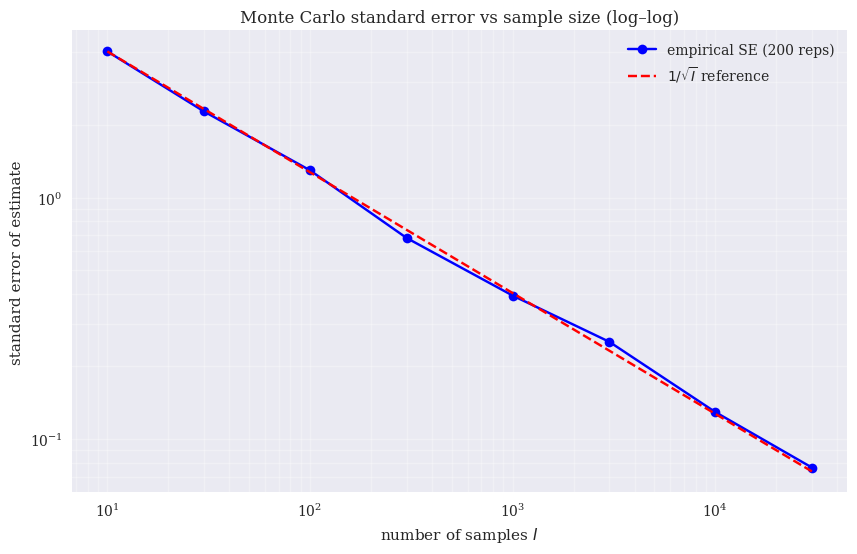

In [42]:
np.random.seed(2024)
sample_sizes = [10, 30, 100, 300, 1000, 3000, 10_000, 30_000]
n_reps = 200
errors = []
for I in sample_sizes:
    ests = [np.mean(f(np.random.random(I) * (b - a) + a)) * (b - a)
            for _ in range(n_reps)]
    se = np.std(ests, ddof=1)
    errors.append(se)
    print(f'I = {I:6d}:  empirical SE = {se:.5f}')

plt.figure(figsize=(10, 6))
plt.loglog(sample_sizes, errors, 'bo-', label='empirical SE (200 reps)')
plt.loglog(sample_sizes,
           errors[0] * np.sqrt(sample_sizes[0] / np.array(sample_sizes)),
           'r--', label=r'$1/\sqrt{I}$ reference')
plt.xlabel('number of samples $I$')
plt.ylabel('standard error of estimate')
plt.legend(loc=0); plt.grid(True, which='both', alpha=0.3)
plt.title('Monte Carlo standard error vs sample size (log–log)')

The log–log plot makes the convergence rate self-evident: the blue line of empirical standard errors lies almost exactly on the red $1/\sqrt{I}$ reference. From $I = 10$ to $I = 30{,}000$ — a factor of $3{,}000$ in sample size — the standard error drops by a factor of $\sqrt{3{,}000} \approx 55$, exactly as predicted.

> **The 1/√I tax.** Cutting Monte Carlo error in half costs **four times** as many paths. Cutting it by 10 costs 100 times as many paths. This is what makes variance reduction (and quasi-Monte Carlo, which can achieve nearly $1/I$ rates on smooth integrands) so valuable in production pricing systems.

## 11.5 Symbolic Computation

So far every computation has been **numeric**: floating-point inputs in, floating-point outputs out, with all intermediate algebra absorbed into compiled code. Symbolic computation flips this around — we manipulate **mathematical expressions as data**, performing exact algebra in the way a textbook would. The library of choice in Python is **SymPy**, a pure-Python computer algebra system in the spirit of Mathematica or Maple but free and tightly integrated with the scientific stack.

Where this matters in finance:

- **Closed-form Greeks** — first and higher-order derivatives of an option price with respect to inputs, derived once and compiled to fast numerical code.
- **Calibration intermediates** — partial derivatives of a model's pricing formula with respect to its parameters, used by gradient-based calibrators.
- **Pricing formulas** — Black–Scholes is famously closed-form; many of its extensions (constant elasticity of variance, Heston for some moment functionals, jump-diffusion under specific assumptions) admit semi-closed forms that SymPy can derive from first principles.
- **Stochastic calculus pedagogy** — symbolic Itô calculus libraries built on SymPy keep the algebra honest while one is learning.

### 11.5.1 Basics

The fundamental building block is the `Symbol`. Once a symbol is declared, expressions involving it are stored as expression trees rather than evaluated.

In [43]:
xs = sy.Symbol('x')
ys = sy.Symbol('y')

print('type of xs:        ', type(xs).__name__)
print('sy.sqrt(xs):        ', sy.sqrt(xs))
print('3 + sy.sqrt(xs) - 16:', 3 + sy.sqrt(xs) - 4 ** 2)

f_sym = xs ** 2 + 3 + 0.5 * xs ** 2 + 3 / 2
print('raw expression:    ', f_sym)
print('simplified:        ', sy.simplify(f_sym))

type of xs:         Symbol
sy.sqrt(xs):         sqrt(x)
3 + sy.sqrt(xs) - 16: sqrt(x) - 13
raw expression:     1.5*x**2 + 4.5
simplified:         1.5*x**2 + 4.5


Several things to notice:

- **`sy.sqrt(xs)`** returns the symbolic expression `sqrt(x)` — not a number. SymPy never numerically evaluates anything unless asked, so $\sqrt{x}$ stays as $\sqrt{x}$ until it has a value to plug in.
- **Numeric simplification happens automatically** in `3 + sy.sqrt(xs) - 16 = sqrt(x) - 13`. SymPy collected the constants without being told.
- **`sy.simplify()`** is the explicit rewriter. It reduces $x^2 + 3 + 0.5 x^2 + 1.5$ to $1.5 x^2 + 4.5$ — the algorithmic equivalent of "combine like terms".

This is more than convenience: SymPy expressions compose with arbitrary depth, and you can apply simplification, expansion, factoring, or substitution at any node.

In [44]:
sy.init_printing(pretty_print=False, use_unicode=False)

print('pretty-printed simplified f:')
print(sy.pretty(sy.simplify(f_sym)))
print()
print('pretty-printed sqrt(x) + 0.5:')
print(sy.pretty(sy.sqrt(xs) + 0.5))

pretty-printed simplified f:
     2      
1.5*x  + 4.5

pretty-printed sqrt(x) + 0.5:
  ___      
\/ x  + 0.5


SymPy renders expressions in three formats:

- **LaTeX** — what you get in a Jupyter notebook with `sy.init_printing()`. Visually appealing, MathJax-rendered.
- **Unicode** — for terminals that support it.
- **ASCII** — fallback for environments without Unicode.

We selected ASCII output above to keep the rendering deterministic across platforms. In your own notebooks, the LaTeX renderer is usually the best choice.

#### A whimsical aside — birthdays in $\pi$

A famous demonstration of symbolic computing's reach is the on-demand evaluation of $\pi$ to arbitrary precision. SymPy can return the first $n$ digits exactly, and then you can search the resulting string for any pattern.

In [45]:
import time
t0 = time.perf_counter()
pi_str = str(sy.N(sy.pi, 40_000))   # 40k digits — modest by SymPy's standards
t1 = time.perf_counter()
print(f'first 40k digits of pi computed in {t1 - t0:.3f} s')
print(f'first 42 chars: {pi_str[:42]}')
print(f'last 40 chars : {pi_str[-40:]}')

# Search for some 6-digit patterns in pi
for needle in ['999999', '271828', '141421']:
    pos = pi_str.find(needle)
    if pos >= 0:
        print(f"   pattern '{needle}': first appears at digit {pos}")
    else:
        print(f"   pattern '{needle}': not found in first 40k digits")

first 40k digits of pi computed in 0.249 s
first 42 chars: 3.1415926535897932384626433832795028841971
last 40 chars : 3907469361988150781468526213325247383765
   pattern '999999': first appears at digit 763
   pattern '271828': first appears at digit 33790
   pattern '141421': not found in first 40k digits


Computing the first $40{,}000$ digits of $\pi$ takes a fraction of a second on a modern CPU thanks to fast multi-precision arithmetic via the `mpmath` backend that SymPy uses internally. The first digits famously begin with $3.14159265\ldots$, and the last few digits look like uniformly distributed noise — exactly as you would expect of an irrational, transcendental number.

We searched for three six-digit patterns:

- **`'999999'`** appears very early — at digit **763**. This is the famous **Feynman point**, named after Richard Feynman, who once joked he'd like to memorize $\pi$ up to that point so he could end with "...999999 and so on", a pun on $\pi$'s irrationality.
- **`'271828'`** (the leading digits of $e$) appears at digit **33,790** — well within our 40k-digit window.
- **`'141421'`** (the leading digits of $\sqrt{2}$) is **not found** in the first 40k digits.

By the **infinite-monkey heuristic**, any six-digit string appears (uniformly distributed) on average every $10^6$ digits, so $40{,}000$ digits give us about a $4\%$ chance of any *particular* target. That `'999999'` and `'271828'` happened to land in this window while `'141421'` did not is consistent with that probability — the first two are lucky draws, the third would require a few hundred thousand more digits on average.

The point is not the numerology but the workflow: **arbitrary-precision arithmetic on demand**. In financial mathematics this same machinery underpins libraries that compute prices accurate to hundreds of digits — useful when validating that a numerical PDE solver is converging, or when computing rare-event probabilities deep in a distribution's tail.

### 11.5.2 Solving equations

`sy.solve(expr)` finds all $x$ satisfying $\text{expr} = 0$. To solve $\text{expr} = c$ for nonzero $c$, rewrite as $\text{expr} - c = 0$.

In [46]:
print('solve x^2 - 1 = 0:        ', sy.solve(xs ** 2 - 1))
print('solve x^2 - 4 = 0:        ', sy.solve(xs ** 2 - 1 - 3))
print('solve x^3 + 0.5 x^2 - 1 = 0:')
for root in sy.solve(xs ** 3 + 0.5 * xs ** 2 - 1):
    print(f'   {root}')
print('solve x^2 + y^2 = 0 (in x):')
for root in sy.solve(xs ** 2 + ys ** 2, xs):
    print(f'   {root}')

solve x^2 - 1 = 0:         [-1, 1]
solve x^2 - 4 = 0:         [-2, 2]
solve x^3 + 0.5 x^2 - 1 = 0:
   0.858094329496553
   -0.679047164748276 - 0.839206763026694*I
   -0.679047164748276 + 0.839206763026694*I
solve x^2 + y^2 = 0 (in x):
   -I*y
   I*y


- **Quadratic** — `solve(x**2 - 1)` returns $\{-1, 1\}$, both real roots of $x^2 = 1$. This is the textbook factorization performed symbolically.
- **Shifted quadratic** — `solve(x**2 - 4)` returns $\{-2, 2\}$, demonstrating the rewrite $x^2 = 3 \Leftrightarrow x^2 - 3 = 0$ has been done correctly when we wrote `xs ** 2 - 1 - 3`.
- **Cubic** — `solve(x**3 + 0.5 x^2 - 1)` returns three roots: one real ($\approx 0.858$) and two complex conjugates ($\approx -0.679 \pm 0.839 i$). SymPy applied the cubic formula symbolically and then numerically evaluated the radicals.
- **Two-variable** — `solve(x**2 + y**2, x)` returns $\{x = -iy,\, x = iy\}$ — the only complex roots, since the equation has no real solutions other than $(0, 0)$.

In financial mathematics, the analogue of `solve` is everywhere:

- Implied volatility from a Black–Scholes price: invert $C(\sigma) = C^{\text{market}}$.
- Yield from a bond price: invert $P(y) = P^{\text{market}}$.
- Break-even spread for a CDS: solve a fixed-point.

For these *transcendental* problems SymPy may or may not return a closed form; usually we use `sy.nsolve` for a numerical root with educated initial guesses — exactly as we will in §11.5.4.

### 11.5.3 Integration and differentiation

Symbolic integration is where SymPy starts to feel like cheating. `sy.integrate(expr, x)` computes the **antiderivative** of `expr` with respect to `x`; `sy.integrate(expr, (x, a, b))` evaluates the **definite integral**. Both can mix symbolic and numeric limits.

In [47]:
a_s, b_s = sy.symbols('a b')
integrand = sy.sin(xs) + 0.5 * xs

I_obj = sy.Integral(integrand, (xs, a_s, b_s))
print('the integral object:')
print(sy.pretty(I_obj))
print()

antider = sy.integrate(integrand, xs)
print('the antiderivative F(x):')
print(sy.pretty(antider))

the integral object:
  b                    
  /                    
 |                     
 |  (0.5*x + sin(x)) dx
 |                     
/                      
a                      

the antiderivative F(x):
      2         
0.25*x  - cos(x)


The pretty-printed integral $\int_a^b (0.5 x + \sin x)\, dx$ is just the *unevaluated* expression — SymPy will manipulate it but won't actually solve it until asked. The antiderivative, on the other hand, **has** been computed:

$$F(x) \;=\; 0.25\, x^2 - \cos(x)$$

which is the textbook elementary integral $\int (\sin x + 0.5 x)\, dx = -\cos x + 0.25 x^2 + C$. SymPy returned the version without the integration constant — which is the convention for `integrate` (the constant disappears anyway in any definite integral via the fundamental theorem of calculus).

In [48]:
F_b = antider.subs(xs, 9.5).evalf()
F_a = antider.subs(xs, 0.5).evalf()
print(f'F(9.5) = {F_b}')
print(f'F(0.5) = {F_a}')
print(f'F(9.5) - F(0.5) = {F_b - F_a}')

# Compare to the all-in-one symbolic call
I_def = sy.integrate(integrand, (xs, 0.5, 9.5))
print(f'\nsy.integrate with definite limits: {I_def}')

# And the symbolic-limits version
I_sym = sy.integrate(integrand, (xs, a_s, b_s))
print(f'\nsymbolic-limits antiderivative:')
print(sy.pretty(I_sym))

F(9.5) = 23.5596721561964
F(0.5) = -0.815082561890373
F(9.5) - F(0.5) = 24.3747547180867

sy.integrate with definite limits: 24.3747547180867

symbolic-limits antiderivative:
        2         2                  
- 0.25*a  + 0.25*b  + cos(a) - cos(b)


Three ways of computing the same definite integral, all giving $24.3747547180867$ to fifteen digits — agreeing with the closed-form analytic value $\cos(0.5) - \cos(9.5) + 0.25(9.5^2 - 0.5^2)$ that we derived by hand in §11.4.

The **symbolic-limits version** is interesting:

$$\int_a^b \bigl(\sin x + 0.5 x\bigr)\,dx \;=\; -0.25\, a^2 + 0.25\, b^2 + \cos(a) - \cos(b)$$

This is a **formula**, not a number. We can substitute any $(a, b)$ pair into it and get the corresponding integral *exactly* — no quadrature, no error estimate, just substitution. For pricing applications where you might need to recompute the integral hundreds of millions of times across different limits (e.g., barrier options with moving knockout levels), having a closed form like this is computationally golden.

#### Differentiation and the global-minimum check

The **Fundamental Theorem of Calculus** says that differentiating an antiderivative recovers the original integrand:

$$\frac{d}{dx} F(x) \;=\; f(x)$$

Let's verify symbolically and then use differentiation to **certify** the global minimum we found numerically in §11.3.

In [49]:
print('d/dx of F(x) = 0.25 x^2 - cos(x):')
print('  ', antider.diff(xs))

d/dx of F(x) = 0.25 x^2 - cos(x):
   0.5*x + sin(x)


SymPy returns `0.5*x + sin(x)` — exactly the integrand we started from. Round-trip integration and differentiation cancel, as the FTC promises.

#### Symbolic optimality conditions

Recall the global-minimum problem from §11.3:

$$f_m(x, y) = \sin(x) + 0.05\, x^2 + \sin(y) + 0.05\, y^2$$

The first-order necessary conditions for an interior extremum are

$$\frac{\partial f_m}{\partial x} = \cos(x) + 0.1\, x = 0,\qquad \frac{\partial f_m}{\partial y} = \cos(y) + 0.1\, y = 0$$

Both conditions are **transcendental** (mixed trig-and-polynomial) and have no closed-form solution. But once we have an "educated guess" — from the brute-force grid search of §11.3 — we can polish to arbitrary precision symbolically.

In [50]:
fm_sym = (sy.sin(xs) + 0.05 * xs ** 2
          + sy.sin(ys) + 0.05 * ys ** 2)

del_x = sy.diff(fm_sym, xs)
del_y = sy.diff(fm_sym, ys)
print('df/dx =', del_x)
print('df/dy =', del_y)

# Educated guess from the numerical work in 11.3:
xo_good = sy.nsolve(del_x, -1.5)
yo_good = sy.nsolve(del_y, -1.5)
val_good = fm_sym.subs({xs: xo_good, ys: yo_good}).evalf()

print(f'\neducated guess (-1.5, -1.5):')
print(f'  x* = {xo_good}')
print(f'  y* = {yo_good}')
print(f'  f_m(x*, y*) = {val_good}')

# Uneducated guess to demonstrate basin-trapping:
xo_bad = sy.nsolve(del_x, 1.5)
yo_bad = sy.nsolve(del_y, 1.5)
val_bad = fm_sym.subs({xs: xo_bad, ys: yo_bad}).evalf()
print(f'\nuneducated guess (+1.5, +1.5):')
print(f'  x* = {xo_bad}')
print(f'  y* = {yo_bad}')
print(f'  f_m(x*, y*) = {val_bad}')

df/dx = 0.1*x + cos(x)
df/dy = 0.1*y + cos(y)

educated guess (-1.5, -1.5):
  x* = -1.42755177876459
  y* = -1.42755177876459
  f_m(x*, y*) = -1.77572565314742

uneducated guess (+1.5, +1.5):
  x* = 1.74632928225285
  y* = 1.74632928225285
  f_m(x*, y*) = 2.27423381055640


Two starting guesses, two completely different stationary points:

- **Started near $-1.5$** — `nsolve` converges to $x^* = y^* = -1.42755177876459$, with $f_m \approx -1.7757256531\ldots$. This is the **global minimum** to fifteen digits — a tight refinement of the $-1.7757$ that the numerical optimizer in §11.3 reported.
- **Started near $+1.5$** — `nsolve` converges to $x^* = y^* = +1.74632928225285$, with $f_m \approx +2.2742338105\ldots$. This is a **local minimum on the positive side**, in a different basin.

This is exactly the same trap that the local Nelder–Mead simplex fell into in §11.3.2, now expressed in symbolic-root-finding form. The lesson is the same: **first-order conditions are necessary but not sufficient for global optimality**. To certify a global minimum you also need (a) globally many starting points or a global method, (b) a convexity or curvature argument, or (c) a lower-bounding scheme.

> **Symbolic vs numeric optimization.** Symbolic differentiation produces *exact* gradients, which can be plugged into numerical solvers like `nsolve` for arbitrary-precision answers. This combo — symbolic algebra for the math, numerical solvers for the actual roots — is one of the most productive workflows in quantitative research, especially during the **prototype phase** of a model where you are still figuring out what the gradients ought to look like.

## 11.6 Conclusion

This chapter assembled four tools that recur everywhere in computational finance:

1. **Approximation** via regression and interpolation — for fitting yield curves, vol surfaces, factor models, and the conditional-expectation regressions that drive Longstaff–Schwartz Monte Carlo for American options. We saw that the *basis* matters far more than the *optimizer*: with the right basis (one that contains the truth), least squares recovers exact parameters; with a poor basis, no amount of data fixes the problem.

2. **Convex optimization** — for calibrating models to market quotes, maximizing expected utility, and constructing portfolios under constraints. The two-stage **global → local** workflow is non-negotiable for non-convex objectives, and constraint specification via `scipy.optimize.minimize` (or, for harder problems, **CVXPY** or commercial solvers) is the standard practitioner toolkit.

3. **Numerical integration** — central to risk-neutral pricing, where every derivative price is a discounted expectation. Adaptive quadrature (`sci.quad`) is the right call in 1D; **Monte Carlo** with $1/\sqrt{I}$ convergence is the only practical choice in high dimensions, and variance reduction is what turns it from a textbook curiosity into a production tool.

4. **Symbolic computation** with SymPy — for deriving closed-form intermediates, gradients, and pricing formulas. The combination of symbolic differentiation with numerical root-finding (`nsolve`) is one of the most productive workflows in quantitative research.

A common thread runs through all four: **prior structure beats brute force**. The right basis collapses regression error to zero; the right starting point makes local optimization bulletproof; the right change of variables turns an intractable integral into a one-line antiderivative. Throughout the rest of *Python for Finance*, you will see these same tools applied to **Monte Carlo simulation** (Chapter 12), **derivatives valuation** (Chapter 19), and beyond — always with the same emphasis on combining mathematical knowledge with the right numerical machinery.